## Anomaly Clustering Featurization
* Implement feature extraction from st clusters.
    * time_span, lat_span, lon_span
    * st_volume
    * st_mean_anomaly, st_min_anomaly, st_max_anomaly, st_std_anomaly
    * cluster compactness or eccentricity.
* Present clusters dataframe.
* Present histogram of cluster features.

#### Imports

In [ ]:
from ocean_tools.io.writers import store_pickle_variable
from ocean_tools.visualization.reports import plot_n_clustering_experiment_feature_report
from ocean_tools.processing.clustering import calculate_features_from_extractors
from ocean_tools.config.defaults import CLUSTER_FEATURES_LAMBDA


exports_path = './data/exports/clusters/mv_experiments/features/'

ExperimentSet = {
    'experiment_structure': ['variable_list', 'start_date', 'end_date', 'anomaly_threshold_list', 'eps_t', 'eps_lat', 'eps_lon', 'min_neighbors', 'min_cluster_size', 'experiment_name'],
    'experiments': [
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 300, 1, 'Base Full Period'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 100, 1, 'Smaller Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 500, 1, 'Larger Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 1000, 1, 'Much Larger Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 300, 1, 'Smaller Geo Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 60, 60, 300, 1, 'Larger Geo Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 2, 40, 40, 300, 1, 'Larger Time Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 12, 40, 40, 300, 1, 'Much Larger Time Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 500, 1, '(2) Base Full Period'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 250, 1, '(2) Smaller Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 750, 1, '(2) Larger Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 1000, 1, '(2) Much Larger Min Neighbors'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 10, 10, 500, 1, '(2) Smaller Geo Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 50, 50, 500, 1, '(2) Larger Geo Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 2, 20, 20, 500, 1, '(2) Larger Time Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 12, 20, 20, 500, 1, '(2) Much Larger Time Eps'],
    ]
}

#### Read Stored Clusters

In [ ]:
# Read Stored Clusters.
import pickle
import os

exports_path = './data/exports/clusters/mv_experiments/'
experiment_results = []
for experiment in ExperimentSet['experiments']:
    variable_list, start_date, end_date, anomaly_threshold_list, eps_t, eps_lat, eps_lon, min_neighbors, min_cluster_size, experiment_name = experiment
    file_name = f"clustering_experiment_{start_date}_{end_date}_{'-'.join(variable_list)}_{'-'.join(map(str, anomaly_threshold_list))}_{eps_t}_{eps_lat}_{eps_lon}_{min_neighbors}_{min_cluster_size}.pkl"
    clusters, n_clusters, n_discarded, run_seconds = pickle.load(open(os.path.join(exports_path, file_name), 'rb'))
    experiment_results.append((clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name))

#### Define feature calculations

In [14]:
# Using the default feature extractors.
print(len(CLUSTER_FEATURES_LAMBDA), CLUSTER_FEATURES_LAMBDA)

8 {'time_length': <function <lambda> at 0x000002012BF1BE20>, 'lat_length': <function <lambda> at 0x000002012BF1BEB0>, 'lon_length': <function <lambda> at 0x000002012BF1BF40>, 'cluster_size': <function <lambda> at 0x000002012BF50040>, 'cluster_volume': <function <lambda> at 0x000002012BF500D0>, 'cluster_compactness': <function <lambda> at 0x000002012BF50160>, 'cluster_eccentricity': <function <lambda> at 0x000002012BF501F0>, 'cluster_dispersion': <function <lambda> at 0x000002012BF50280>}


#### Calculate features

In [16]:
experiment_features = []

for experiment_result in experiment_results:
    clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name = experiment_result
    experiment_feature = {
        'file_name': file_name,
        'experiment_name': experiment_name,
    }
    experiment_featurized_clusters = calculate_features_from_extractors(clusters, CLUSTER_FEATURES_LAMBDA, experiment_name)
    experiment_feature['features'] = experiment_featurized_clusters
    experiment_features.append(experiment_feature)

Completed (2) Base Full Period | Run time: 0 minutes.
Completed (2) Smaller Min Neighbors | Run time: 2 minutes.
Completed (2) Larger Min Neighbors | Run time: 0 minutes.
Completed (2) Much Larger Min Neighbors | Run time: 0 minutes.
Completed (2) Smaller Geo Eps | Run time: 0 minutes.
Completed (2) Larger Geo Eps | Run time: 1 minutes.
Completed (2) Larger Time Eps | Run time: 0 minutes.
Completed (2) Much Larger Time Eps | Run time: 0 minutes.


#### Store & Read Results

In [ ]:
exports_path = './data/exports/clusters/mv_experiments/features/'
experiment_features_file_name = 'experiment_features_run_2'
store_pickle_variable(experiment_features, exports_path, experiment_features_file_name)

In [5]:
# Read files if needed.
import pickle
import os

exports_path = './data/exports/clusters/mv_experiments/features/'
experiment_features_1 = pickle.load(open(os.path.join(exports_path, f"experiment_features_run_1.pkl"), 'rb'))
experiment_features_2 = pickle.load(open(os.path.join(exports_path, f"experiment_features_run_2.pkl"), 'rb'))

experiment_features = experiment_features_1 + experiment_features_2

print(f"Number of experiments loaded: {len(experiment_features)}")

Number of experiments loaded: 16


#### Feature Report for all experiments

Experiment: Base Full Period
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_40_40_300_1.pkl
    time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1           2.0        60.0        71.0         502.0          8520.0             0.058920              0.971831           16.343003
2           2.0        38.0        50.0         286.0          3800.0             0.075263              0.960000           13.733120
3           7.0       151.0        87.0        2011.0         91959.0             0.021868              0.953642           29.714110
4           4.0       146.0        48.0         613.0         28032.0             0.021868              0.972603           28.055385
5           6.0       186.0       116.0        3998.0        129456.0             0.030883              0.967742           34.480845
6           1.0        59.0        97.0         508.0          5723.0             0.08876

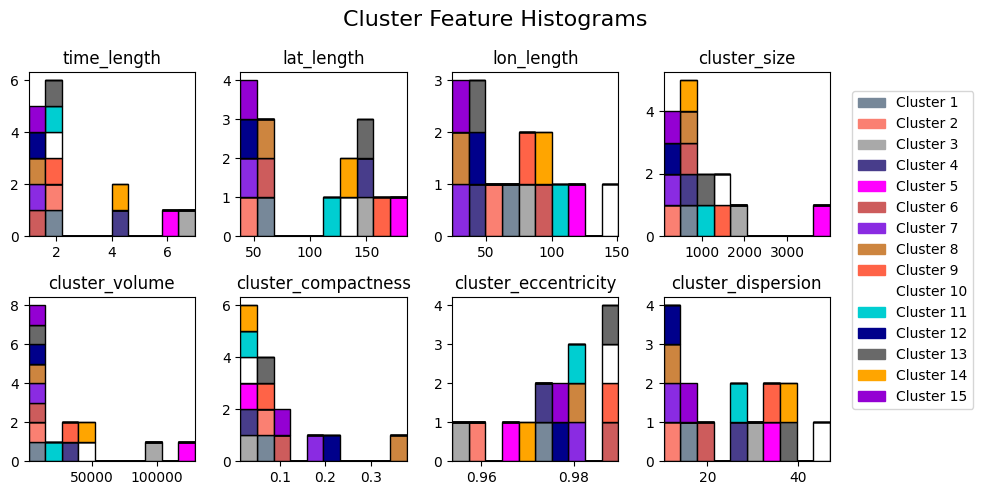

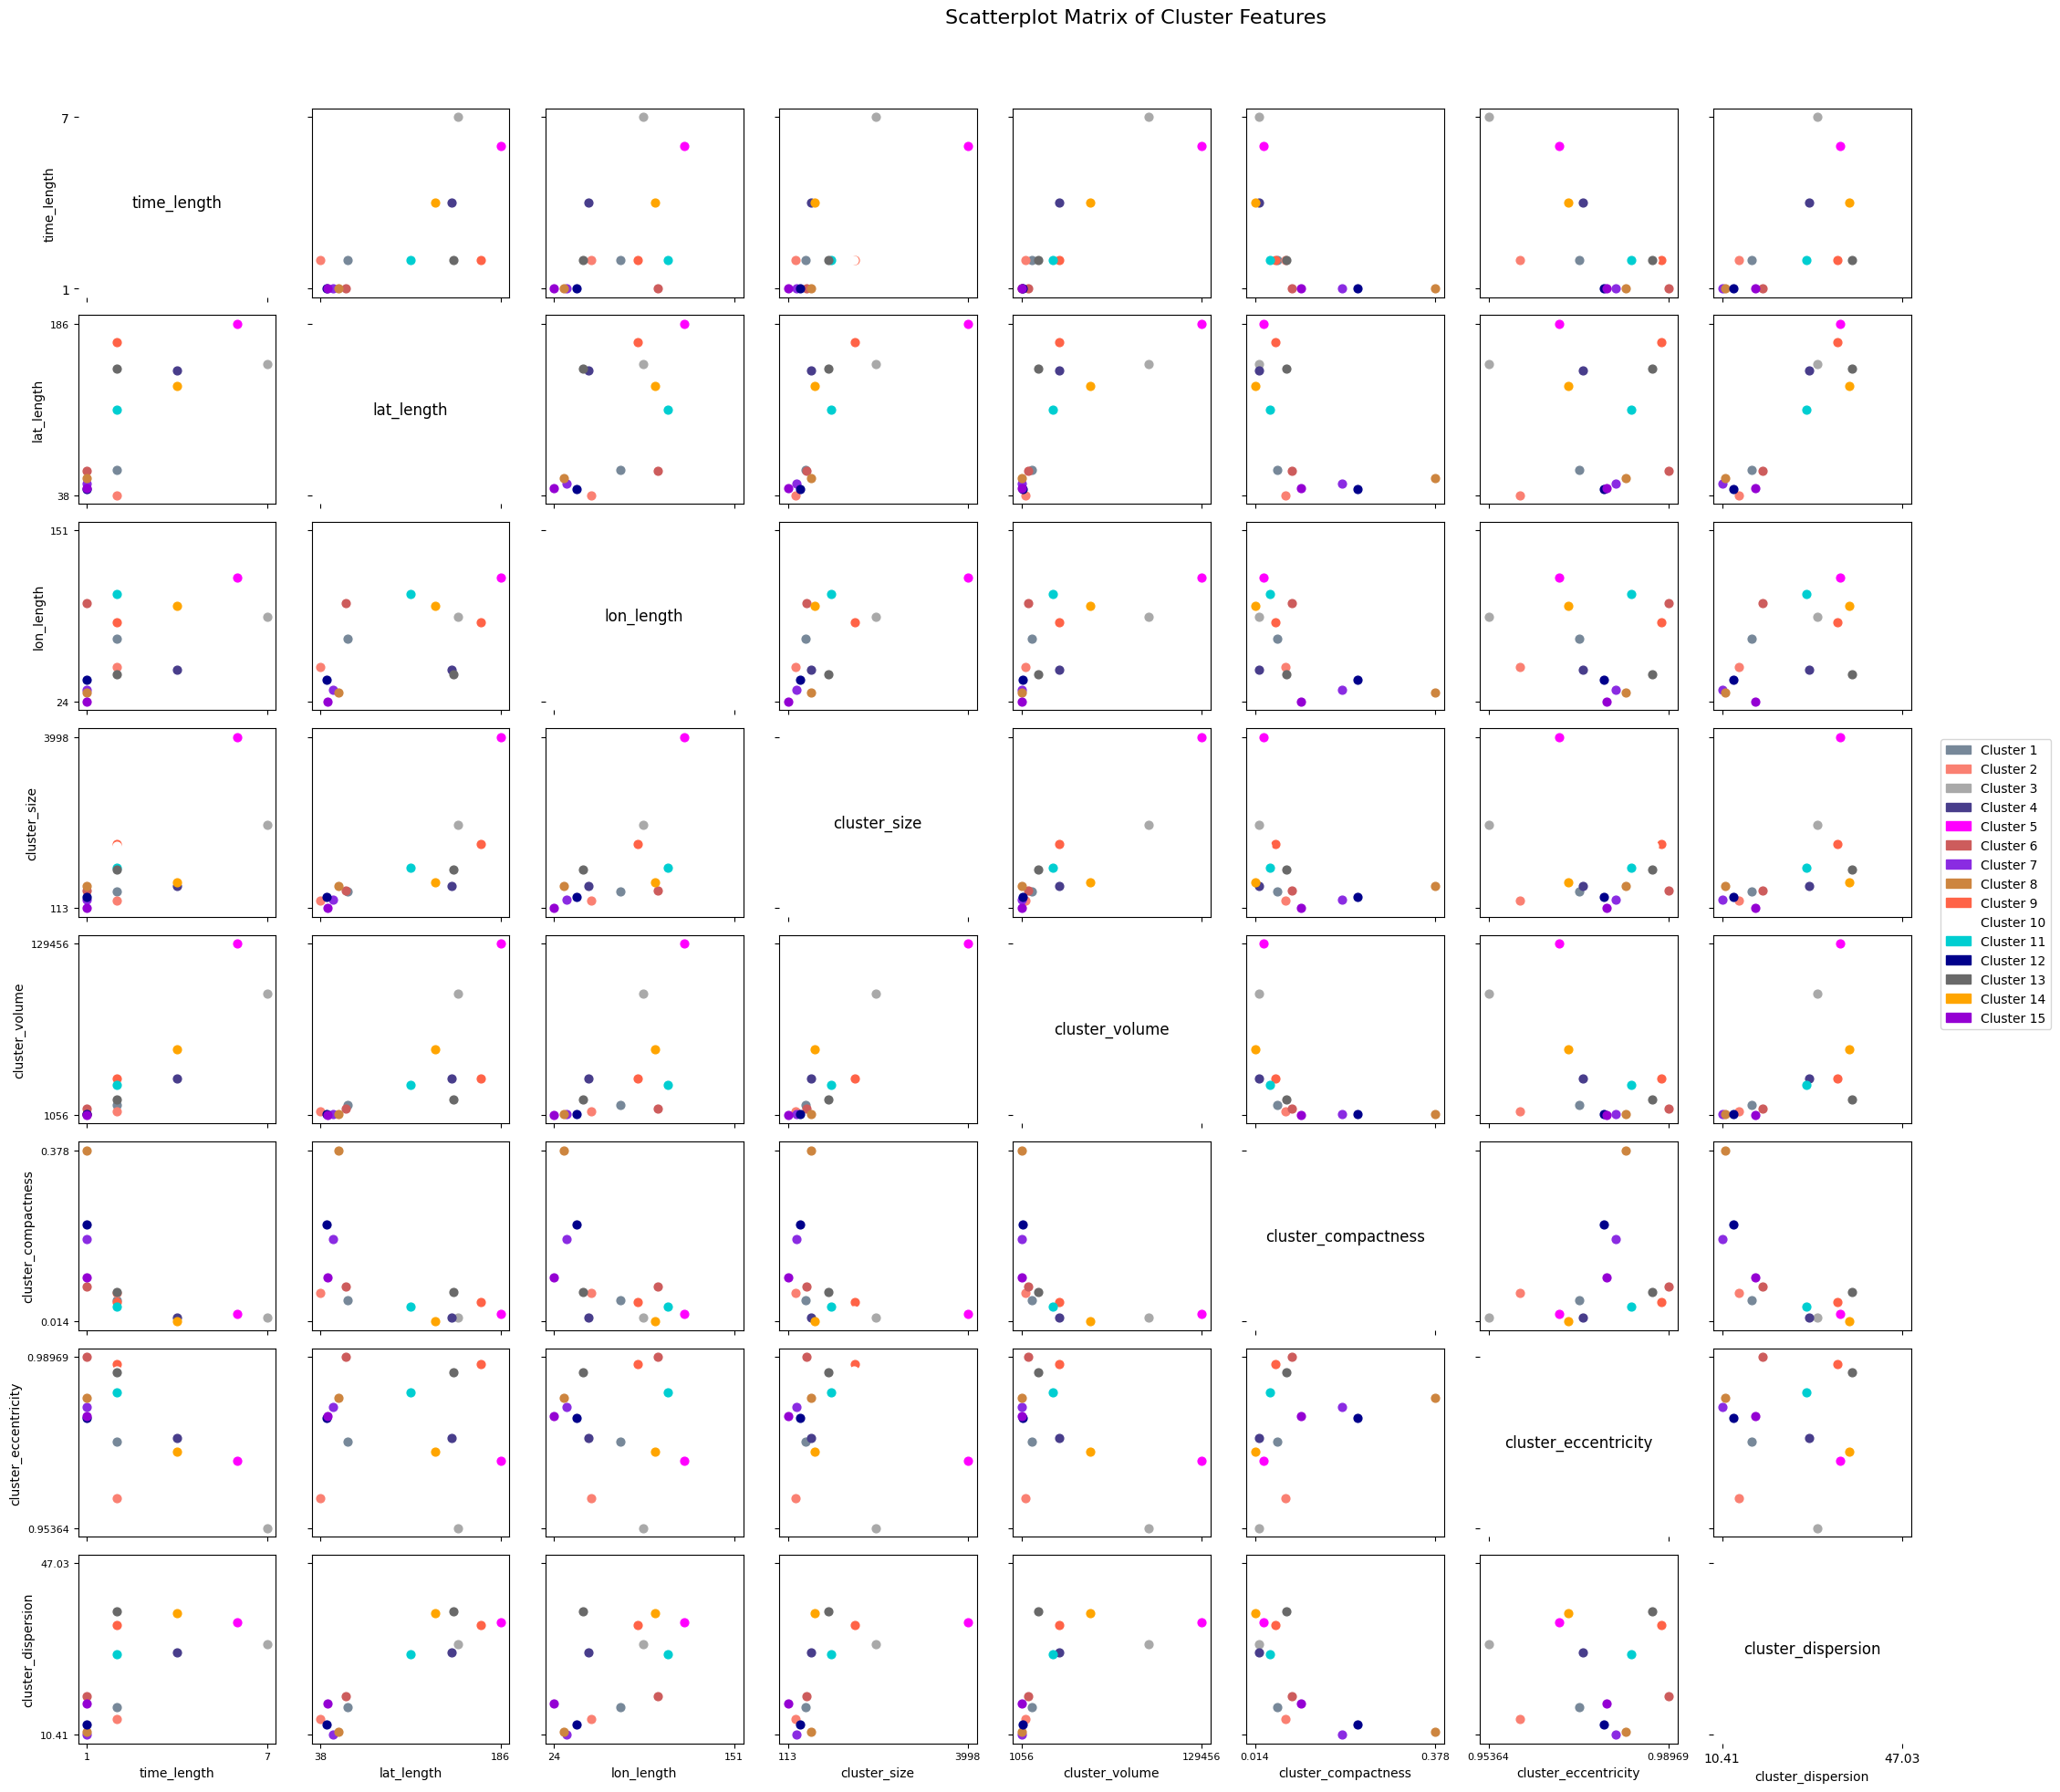




Experiment: Smaller Min Neighbors
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_40_40_100_1.pkl
    time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1           1.0        49.0        38.0         114.0          1862.0             0.061224              0.979592           16.509104
2           2.0        60.0        71.0         502.0          8520.0             0.058920              0.971831           16.343003
3           1.0        39.0        64.0         149.0          2496.0             0.059696              0.984375            5.641820
4           2.0        97.0        99.0         390.0         19206.0             0.020306              0.979798           31.869239
5           2.0        33.0        15.0         115.0           990.0             0.116162              0.939394            8.098693
6           1.0        21.0        15.0         168.0           315.0            

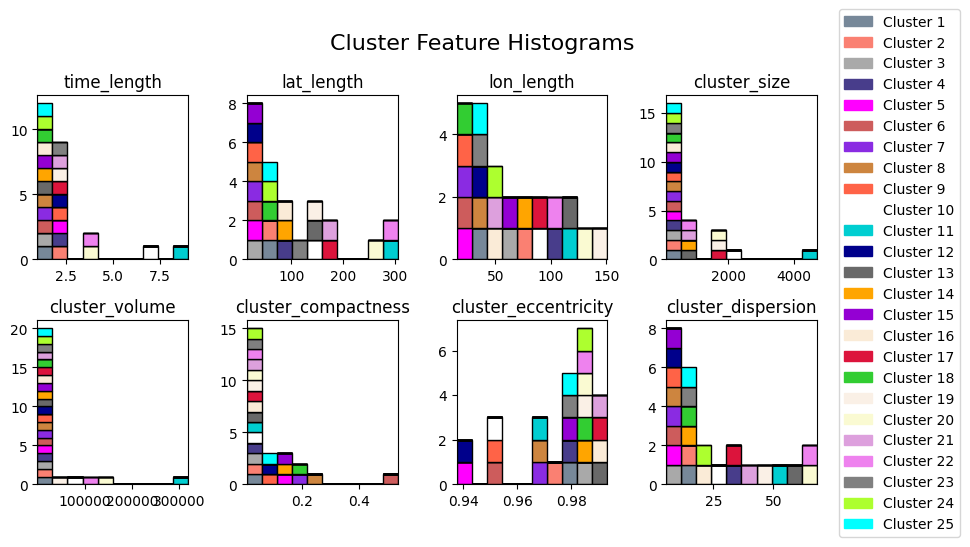

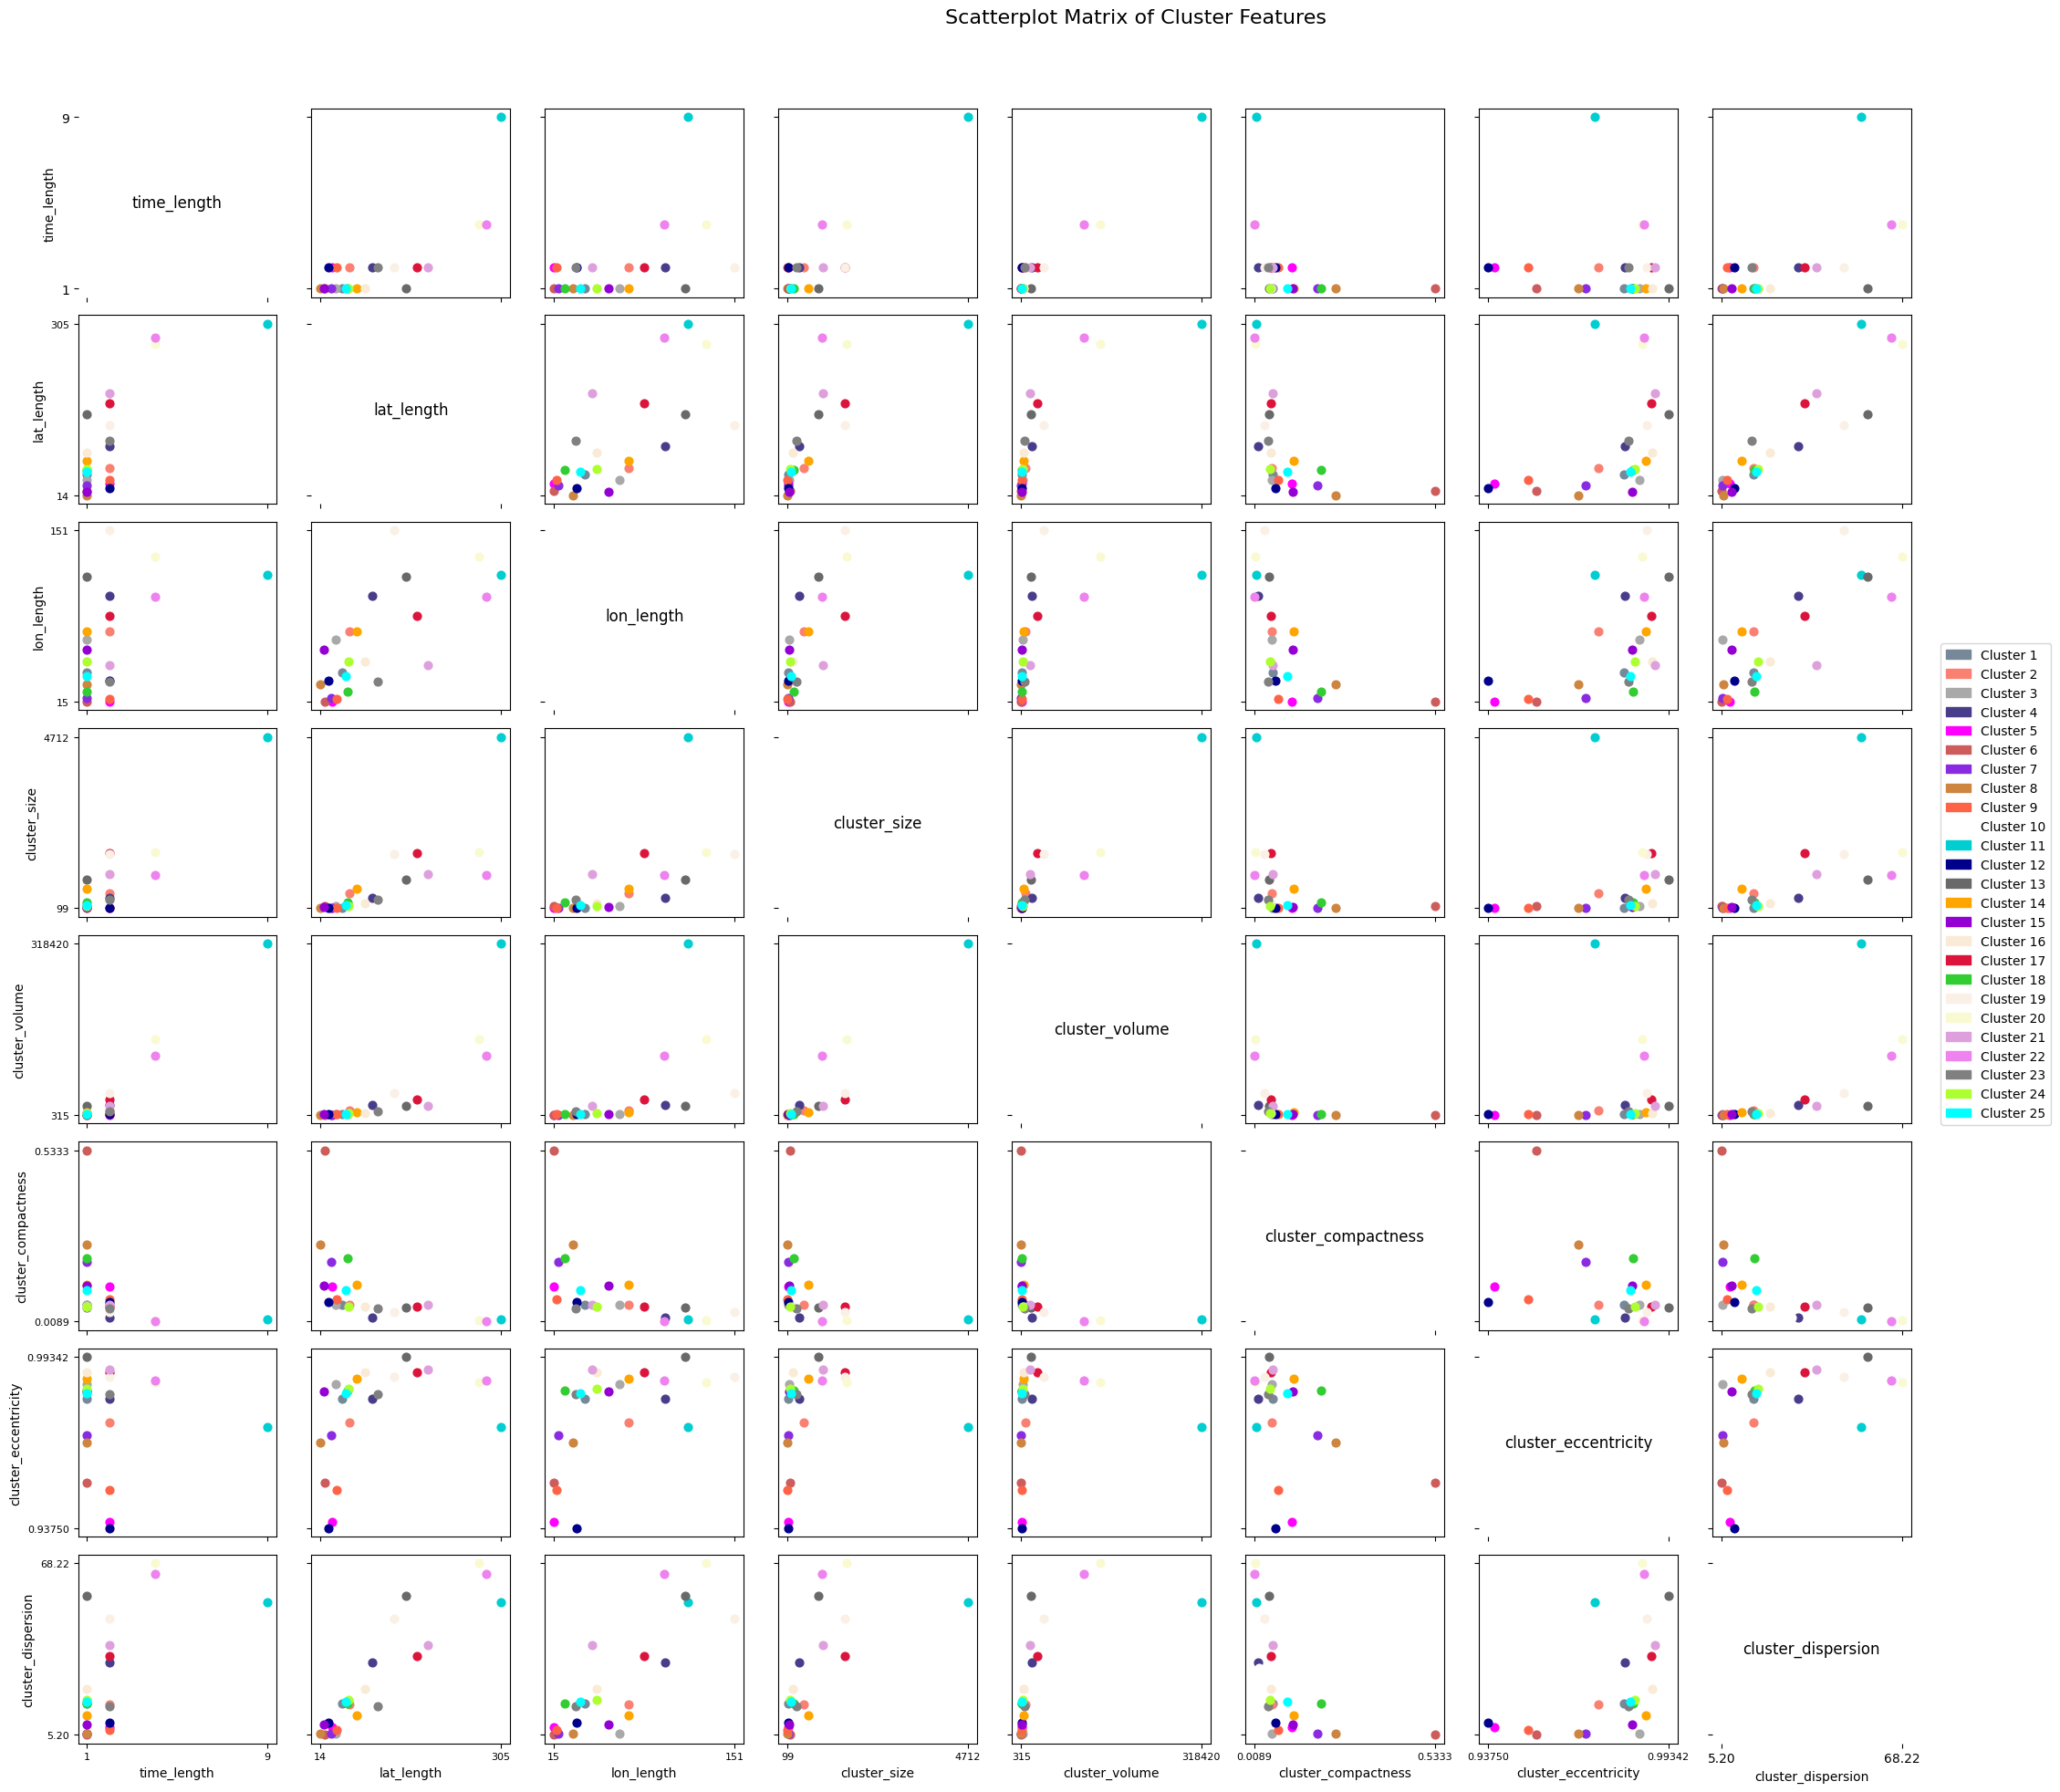




Experiment: Larger Min Neighbors
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_40_40_500_1.pkl
    time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1           2.0        57.0        71.0         353.0          8094.0             0.043613              0.971831           11.399110
2           5.0       122.0        87.0        1934.0         53070.0             0.036442              0.959016           27.566706
3           2.0        94.0        37.0         418.0          6956.0             0.060092              0.978723           22.014515
4           6.0       186.0       116.0        3992.0        129456.0             0.030837              0.967742           34.418586
5           1.0        46.0        31.0         620.0          1426.0             0.434783              0.978261           11.001202
6           2.0       170.0        83.0        1566.0         28220.0             

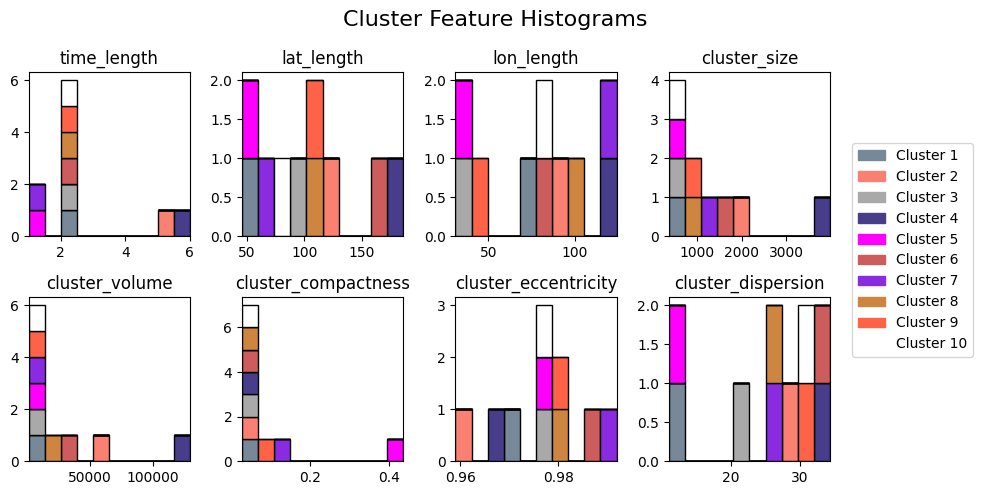

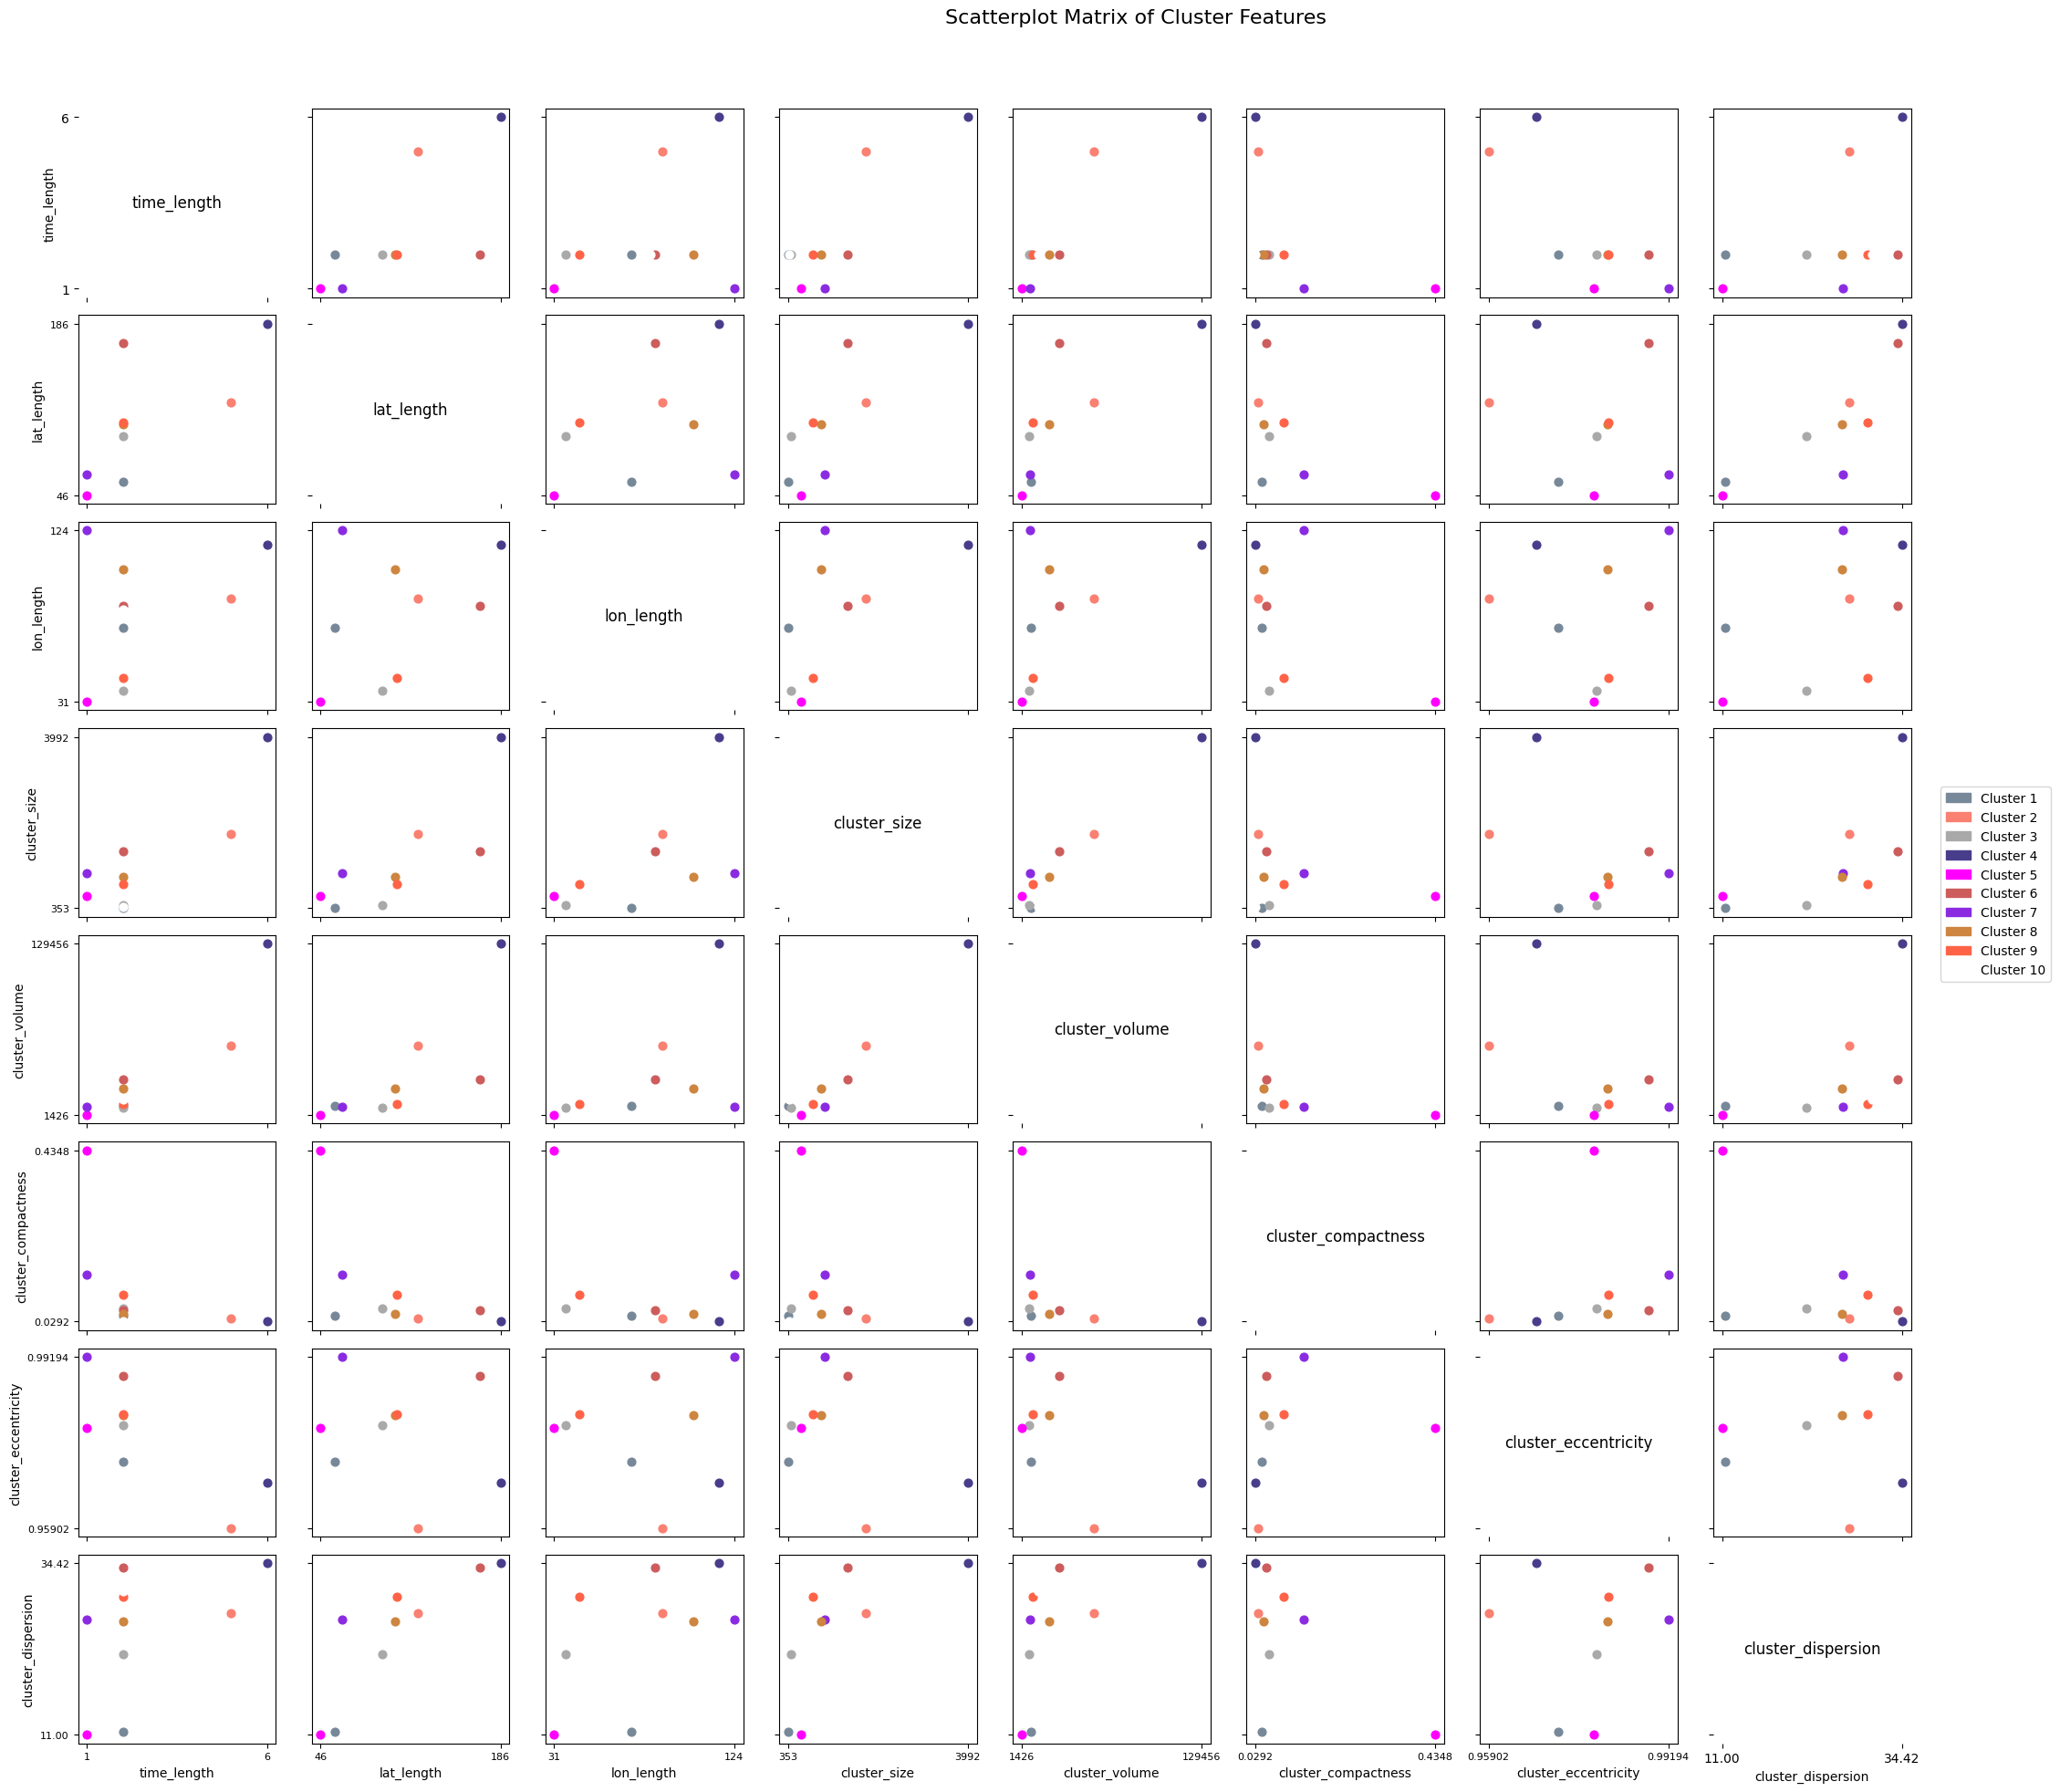




Experiment: Much Larger Min Neighbors
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_40_40_1000_1.pkl
   time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1          3.0        87.0        87.0        1187.0         22707.0             0.052275              0.965517           23.760231
2          4.0       135.0       116.0        3877.0         62640.0             0.061893              0.970370           33.286376
3          1.0        76.0        61.0         964.0          4636.0             0.207938              0.986842           25.007792
4          1.0        48.0        84.0         959.0          4032.0             0.237847              0.988095           25.560445


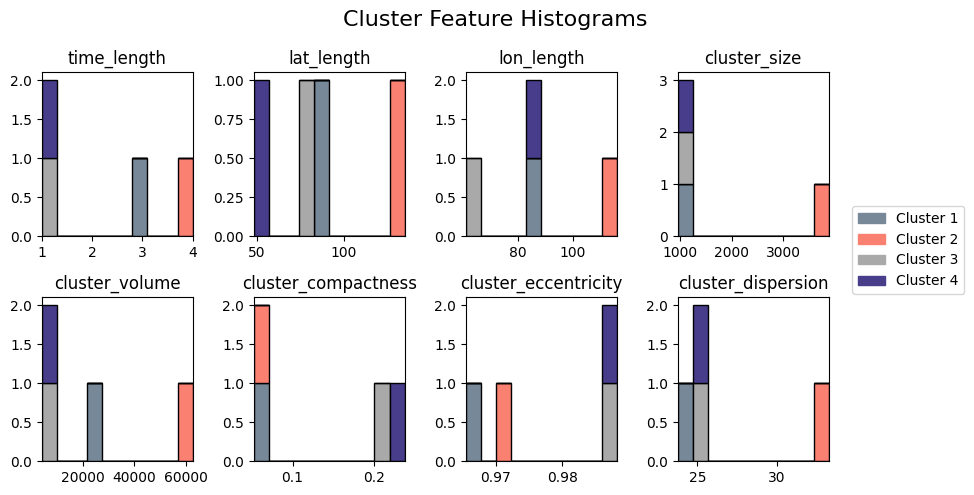

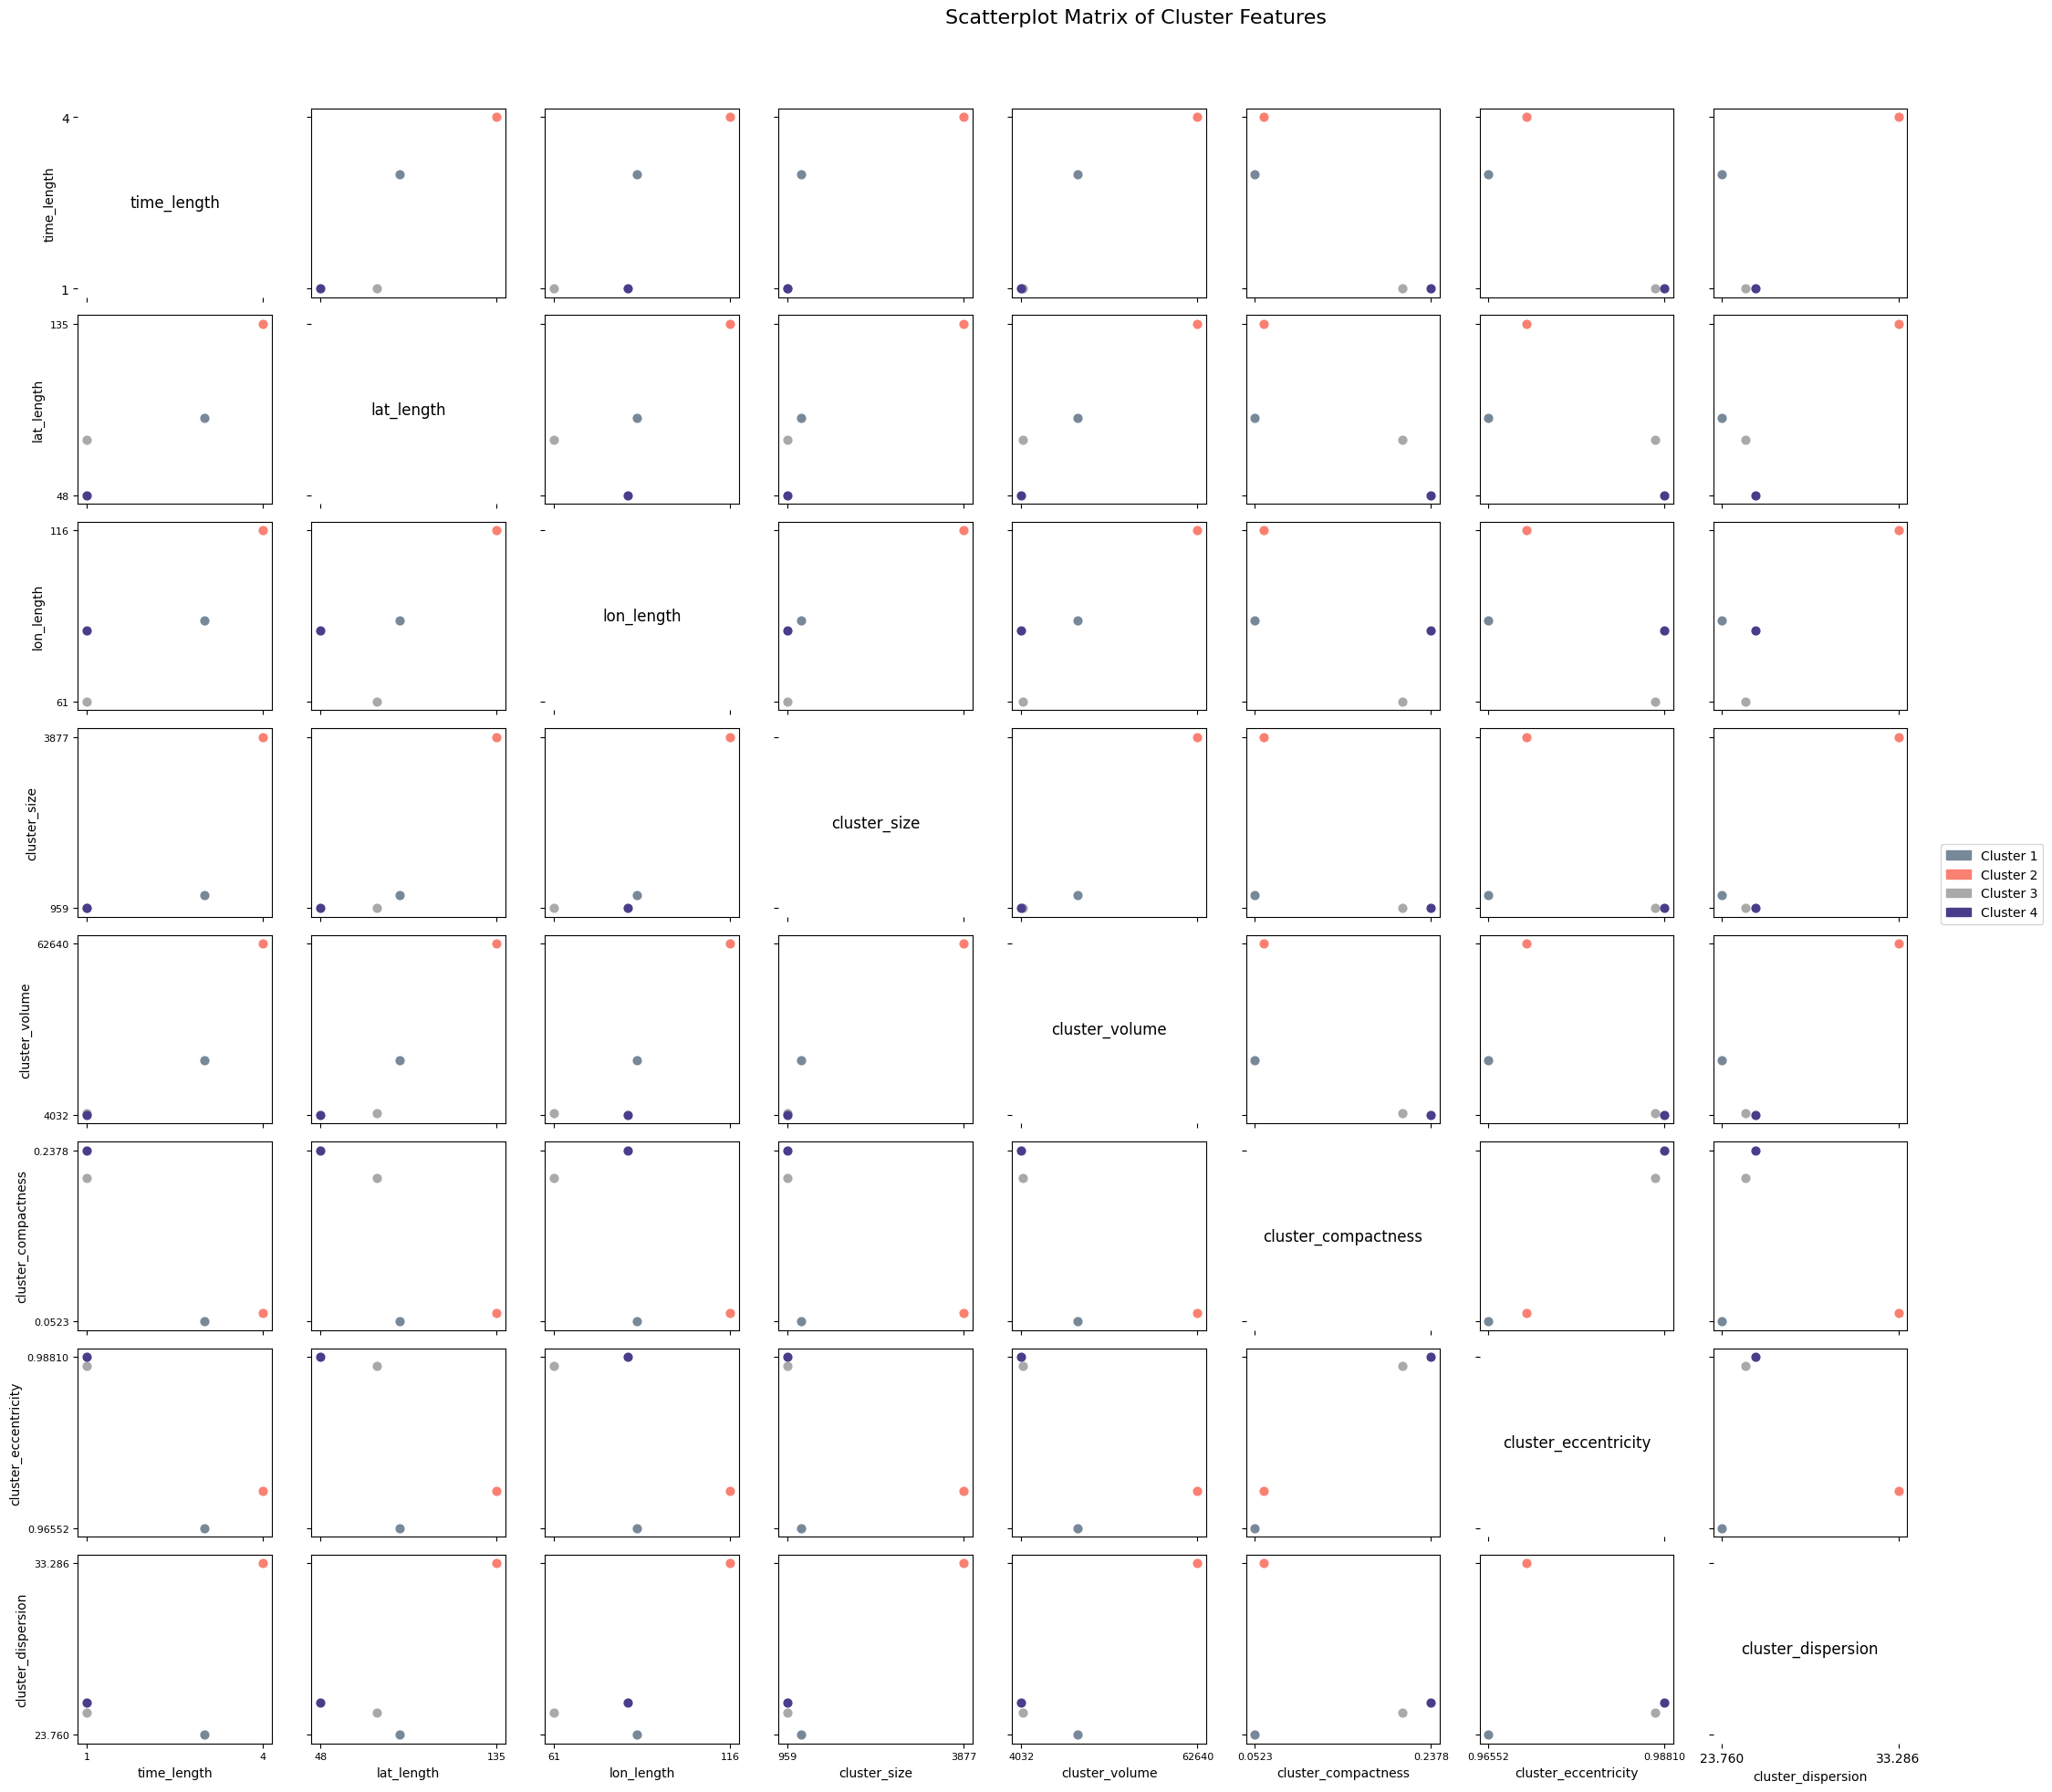




Experiment: Smaller Geo Eps
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_300_1.pkl
    time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1           2.0        45.0        51.0         430.0          4590.0             0.093682              0.960784           13.728961
2           4.0        66.0        70.0        1562.0         18480.0             0.084524              0.942857           18.411011
3           2.0        47.0        20.0         208.0          1880.0             0.110638              0.957447           10.297808
4           4.0       135.0        91.0        3871.0         49140.0             0.078775              0.970370           33.236515
5           1.0        30.0        30.0         416.0           900.0             0.462222              0.966667            8.166901
6           1.0        40.0        29.0         593.0          1160.0             0.511

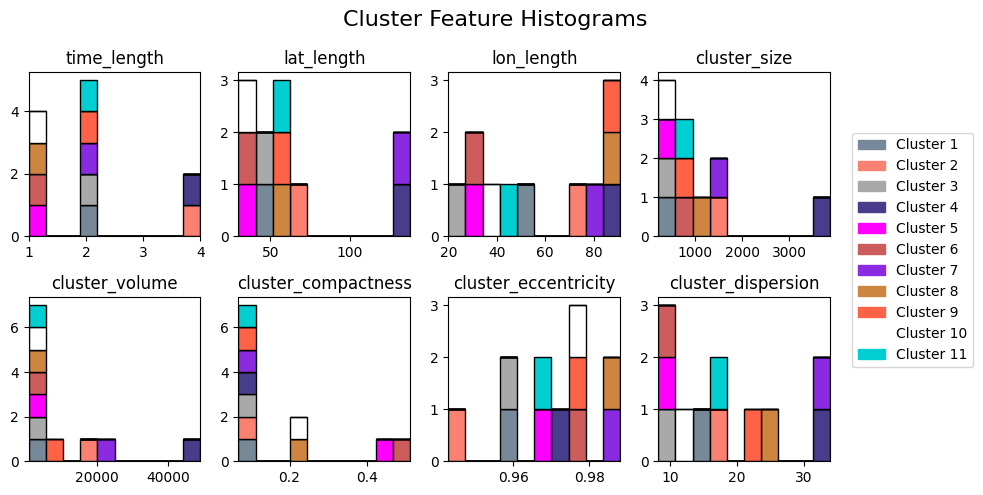

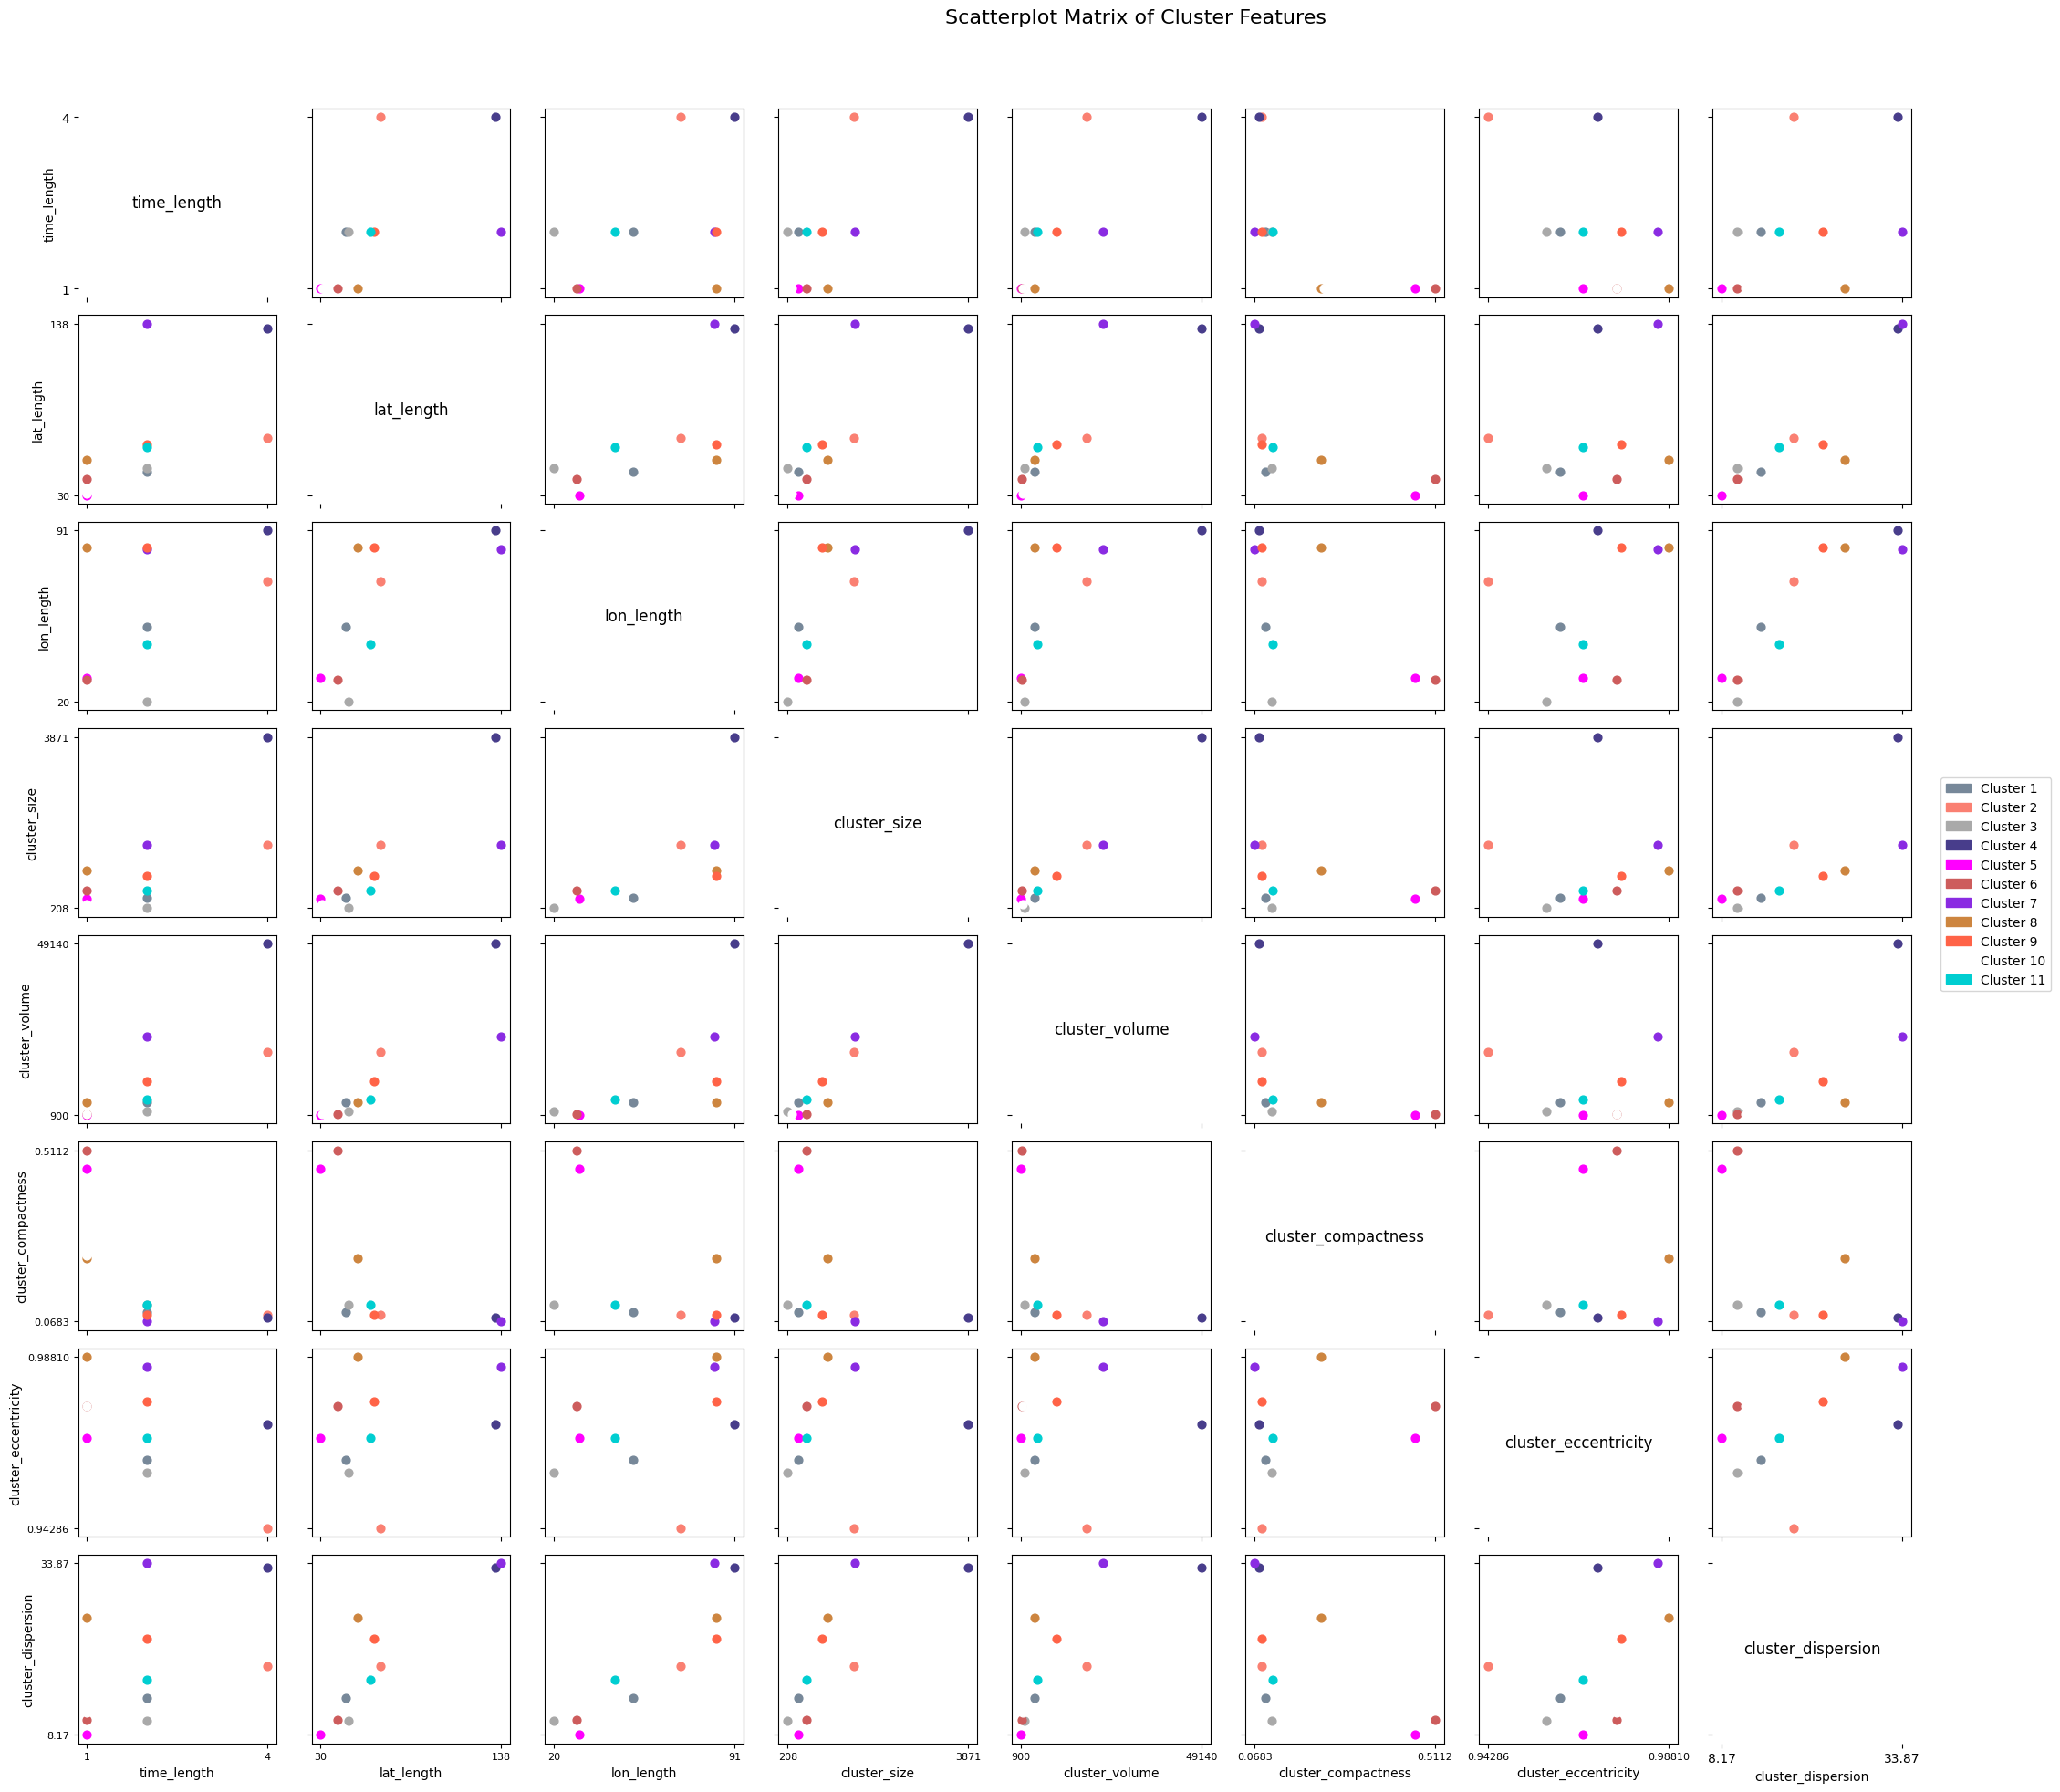




Experiment: Larger Geo Eps
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_60_60_300_1.pkl
    time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1           3.0        60.0        71.0         503.0         12780.0             0.039358              0.957746           16.398861
2           2.0        68.0       100.0         350.0         13600.0             0.025735              0.980000           28.857544
3           7.0       151.0        87.0        2018.0         91959.0             0.021945              0.953642           30.017837
4           4.0       199.0        84.0         727.0         66864.0             0.010873              0.979899           36.157139
5           6.0       190.0       116.0        4017.0        132240.0             0.030377              0.968421           34.924037
6           1.0       152.0       114.0         878.0         17328.0             0.0506

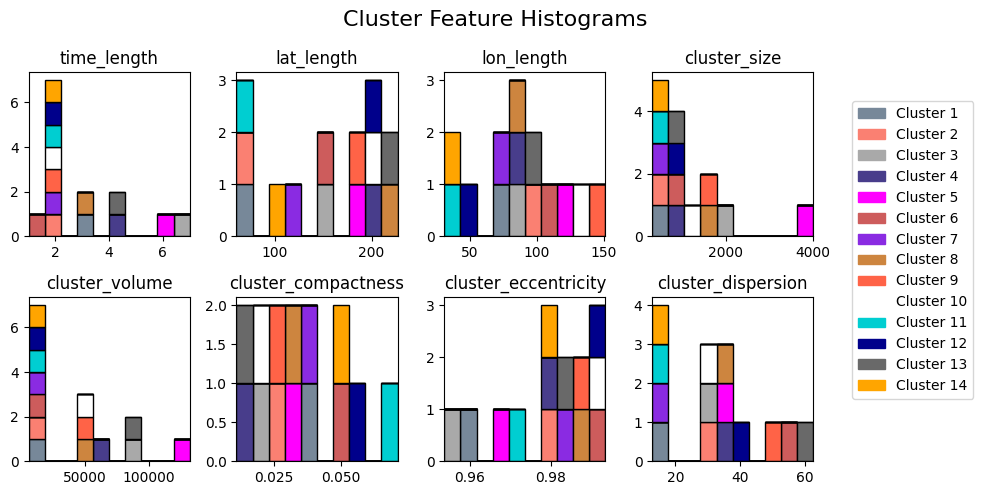

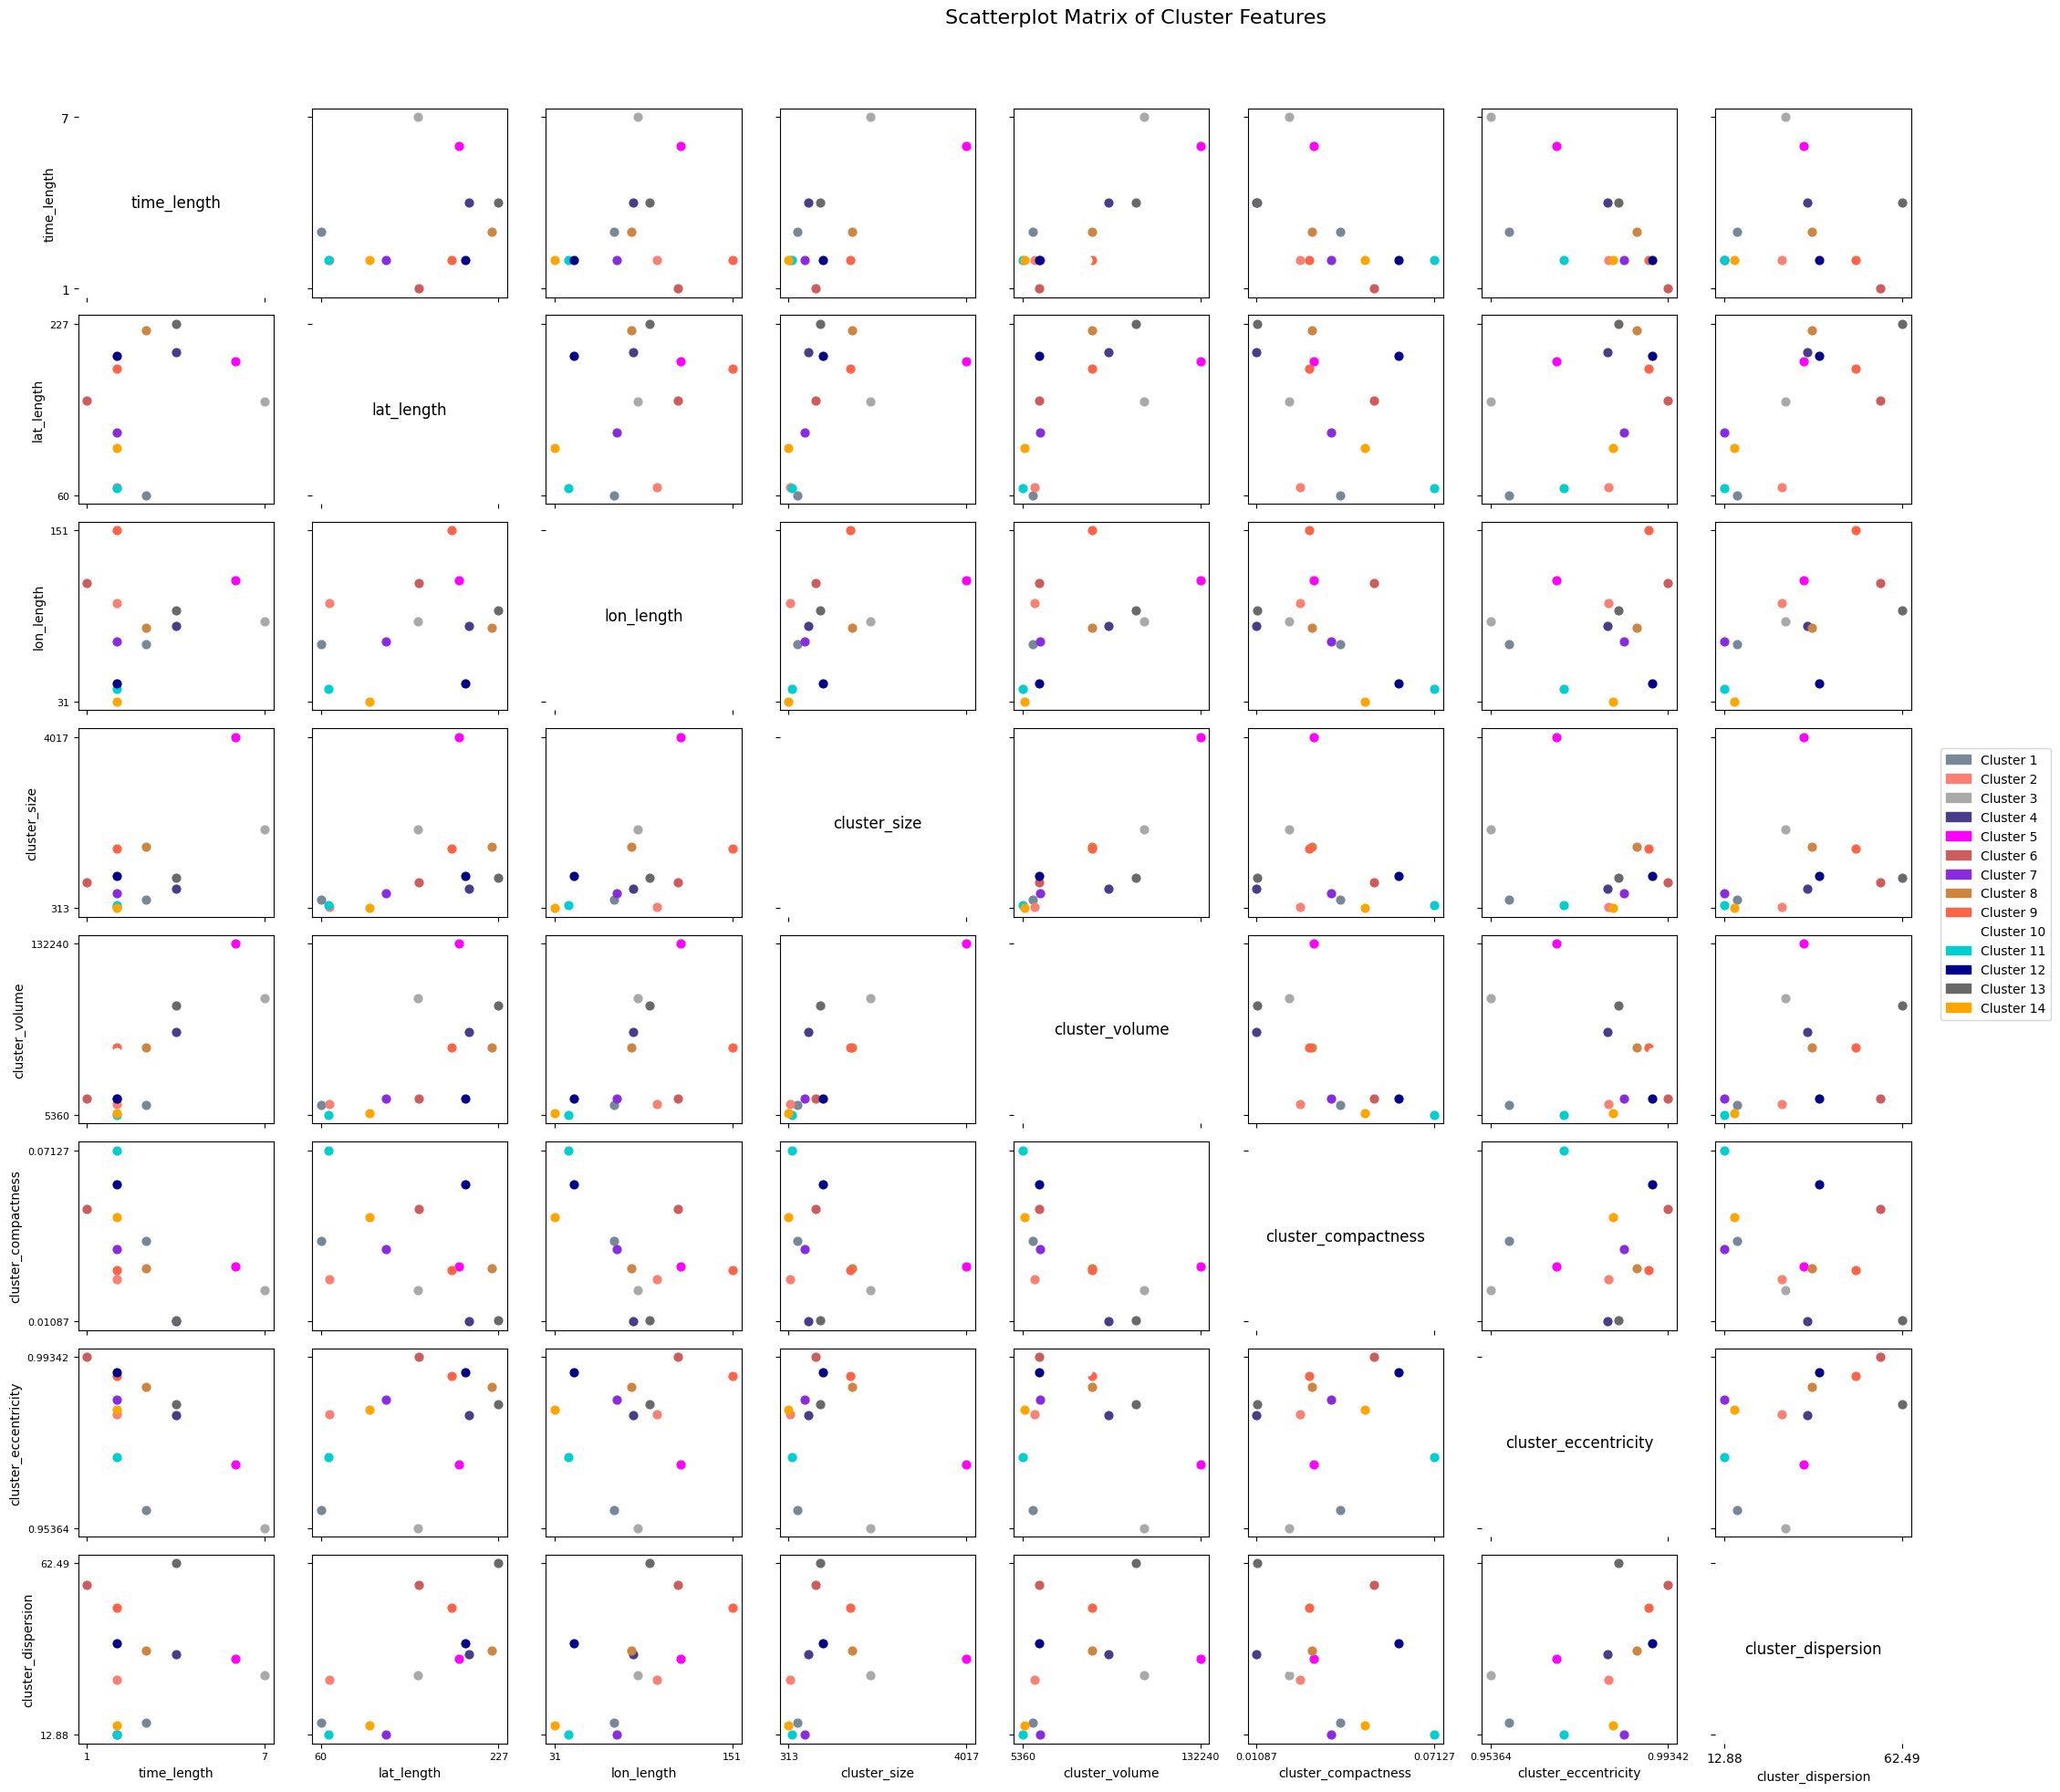




Experiment: Larger Time Eps
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_2_40_40_300_1.pkl
    time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1           3.0        60.0        71.0         503.0         12780.0             0.039358              0.957746           16.398861
2           2.0        38.0        50.0         286.0          3800.0             0.075263              0.960000           13.733120
3           7.0       151.0        87.0        2011.0         91959.0             0.021868              0.953642           29.714110
4           9.0       286.0       116.0        4713.0        298584.0             0.015785              0.968531           53.091427
5           3.0       143.0       120.0        1488.0         51480.0             0.028904              0.979021           52.681208
6           4.0       196.0        83.0        1585.0         65072.0             0.024

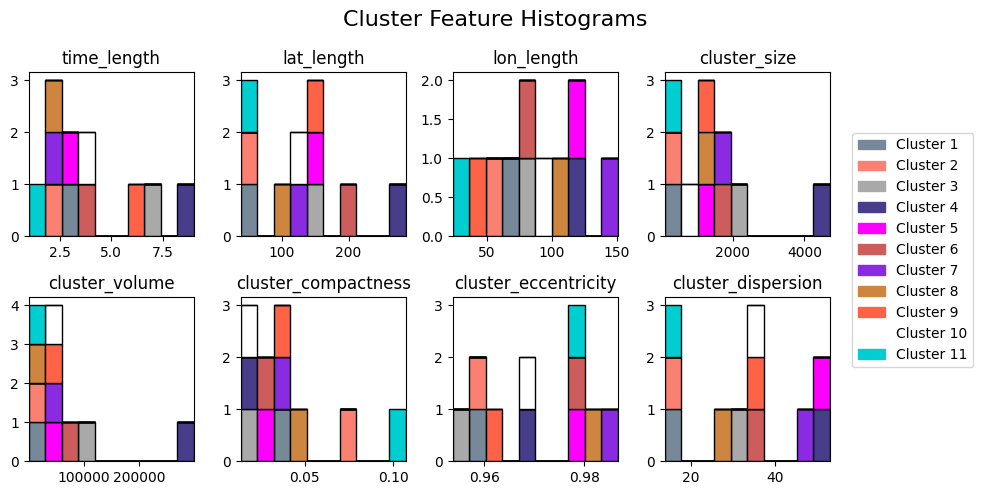

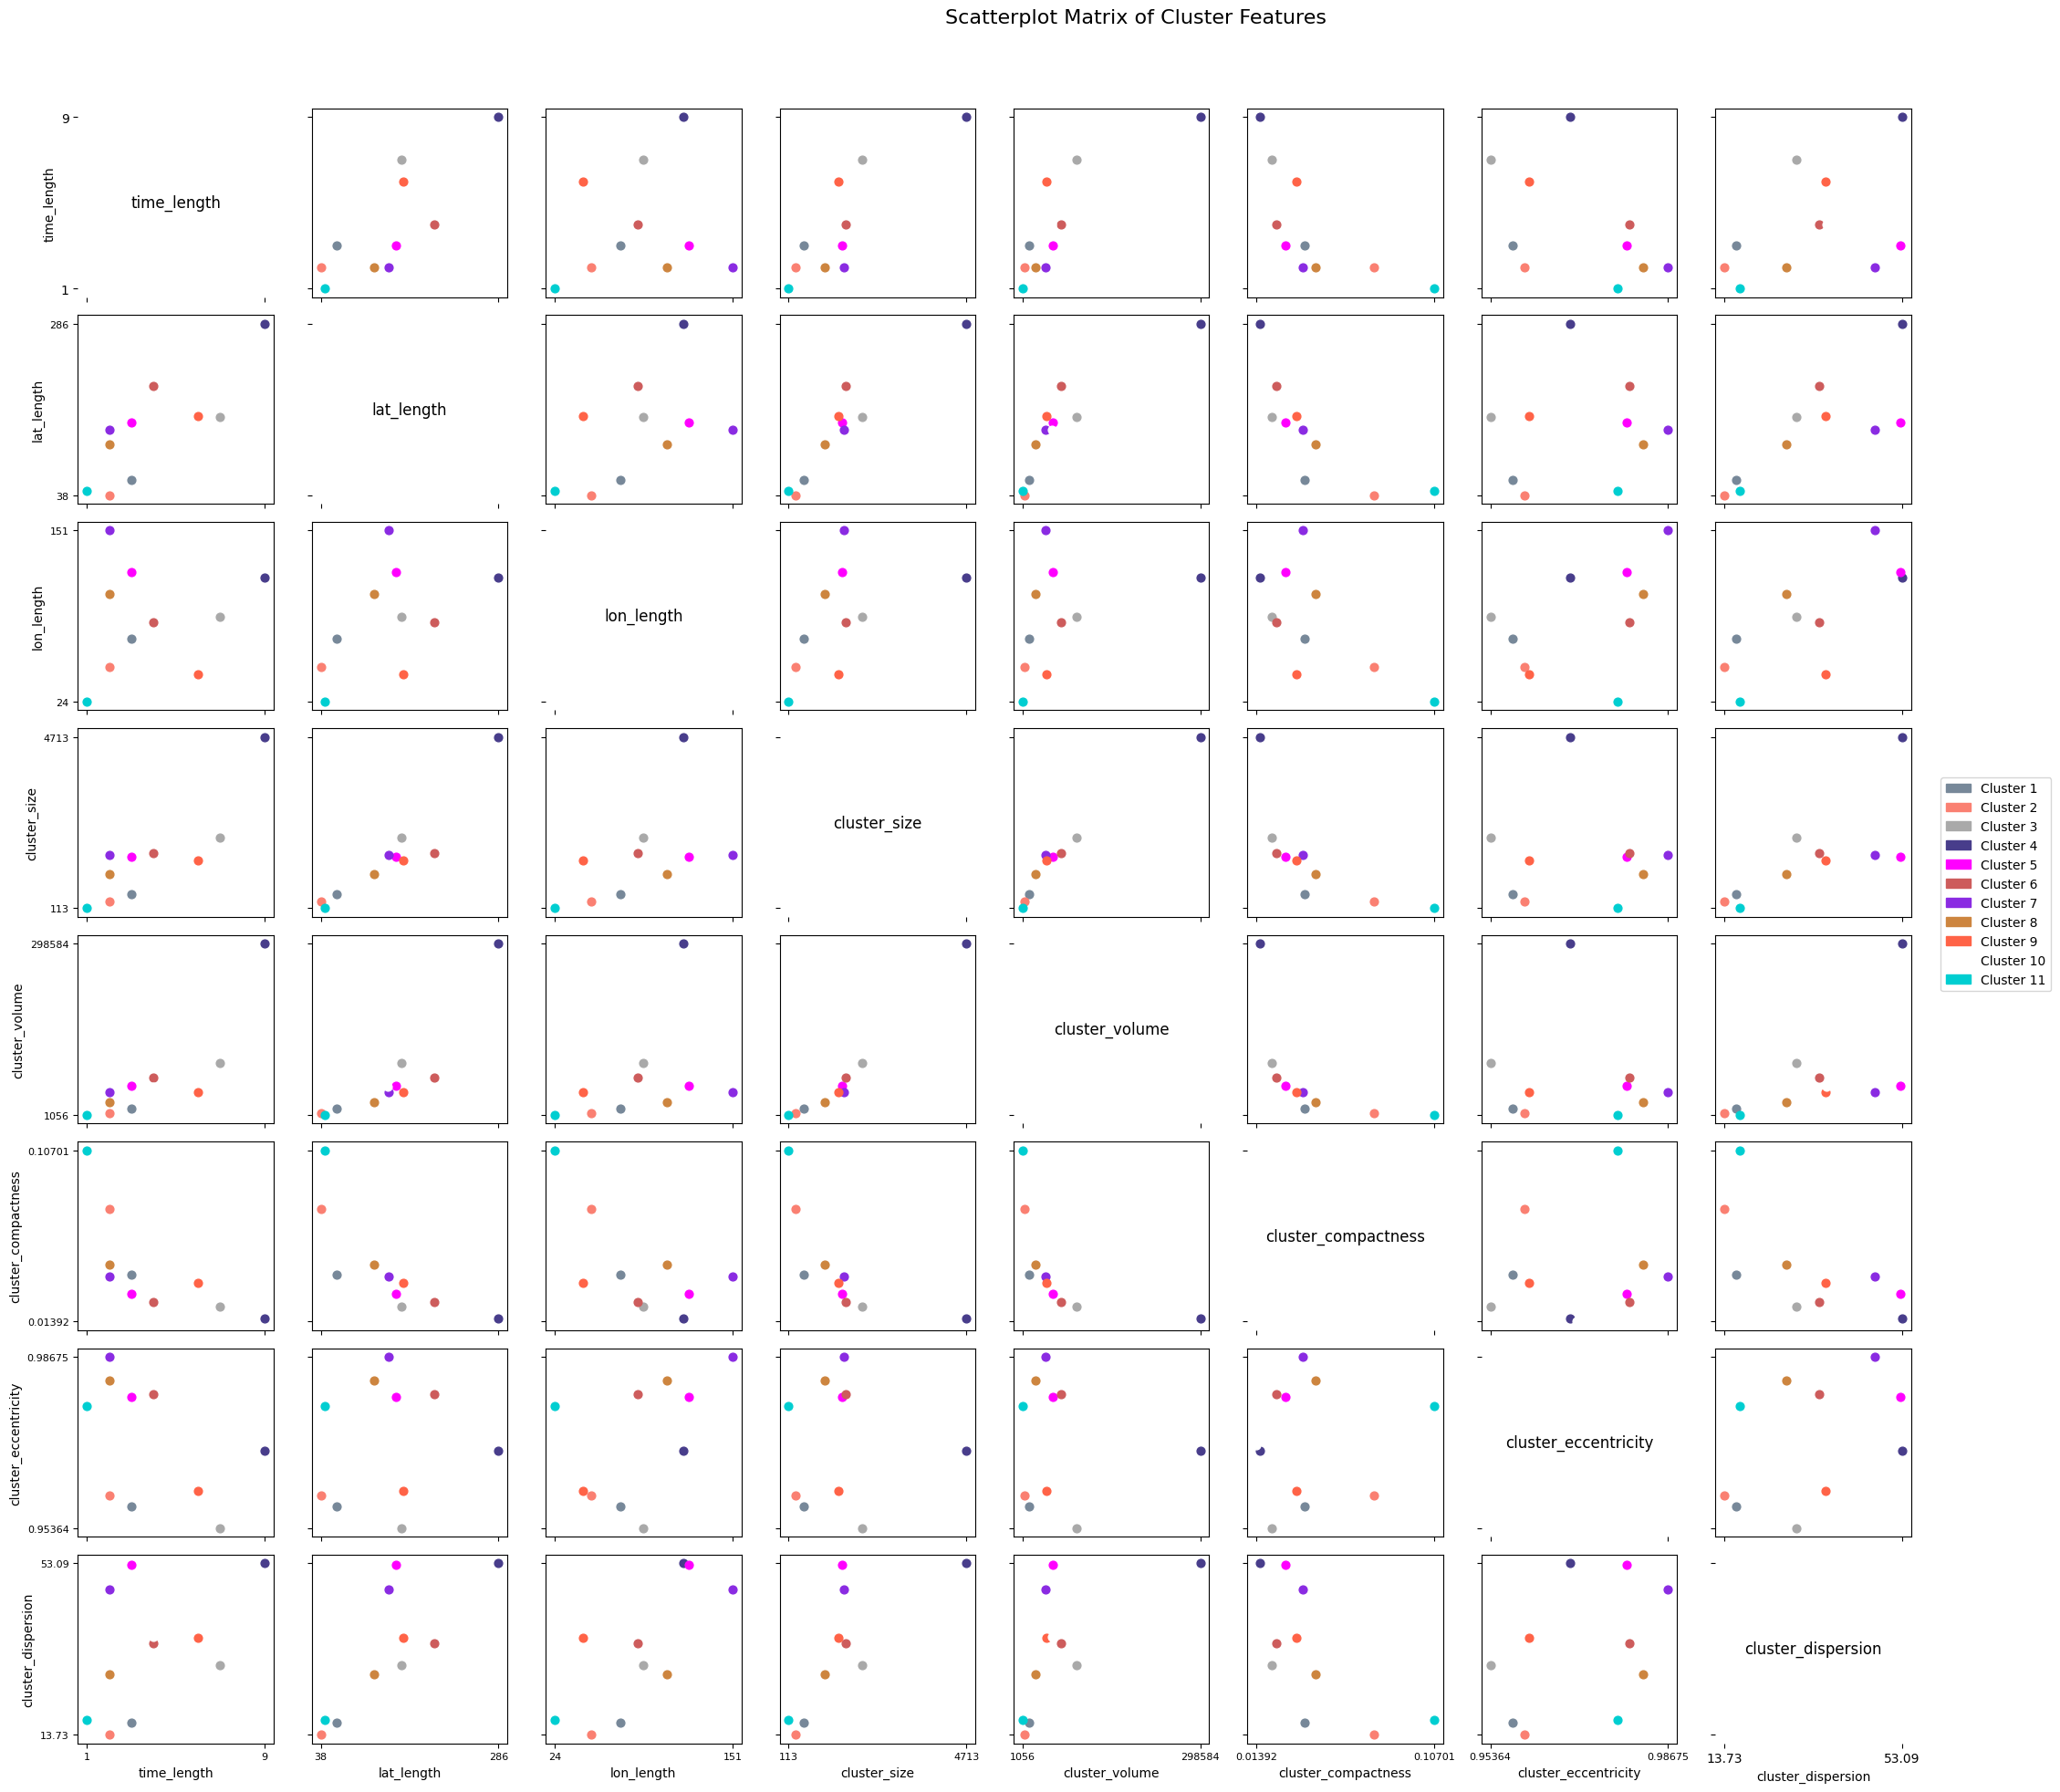




Experiment: Much Larger Time Eps
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_12_40_40_300_1.pkl
   time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1         38.0       108.0        77.0        1016.0        316008.0             0.003215              0.648148           26.265490
2          5.0        47.0        50.0         287.0         11750.0             0.024426              0.900000           13.820938
3         44.0       317.0       116.0        6837.0       1617968.0             0.004226              0.861199           96.316419
4         13.0       183.0       120.0        1551.0        285480.0             0.005433              0.928962           53.930719
5         11.0        86.0        66.0         444.0         62436.0             0.007111              0.872093           20.817775
6         45.0       332.0       151.0        7494.0       2255940.0             0.0033

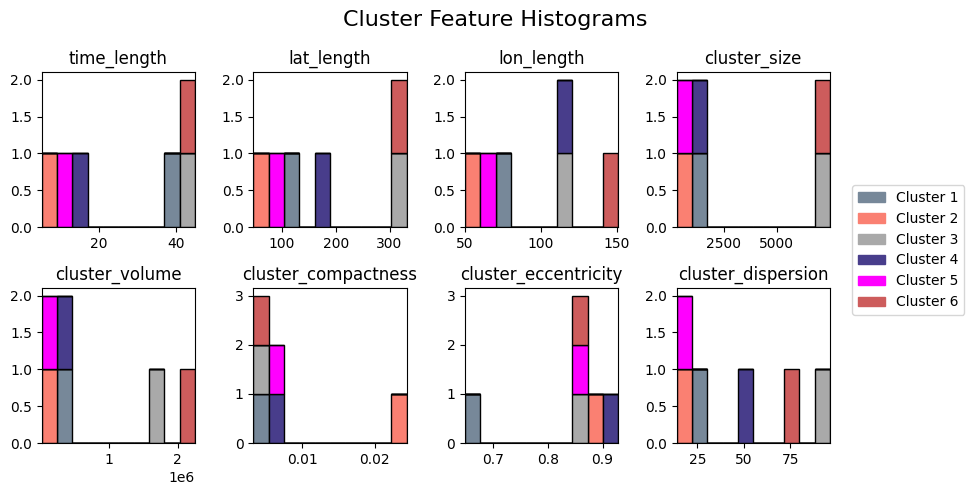

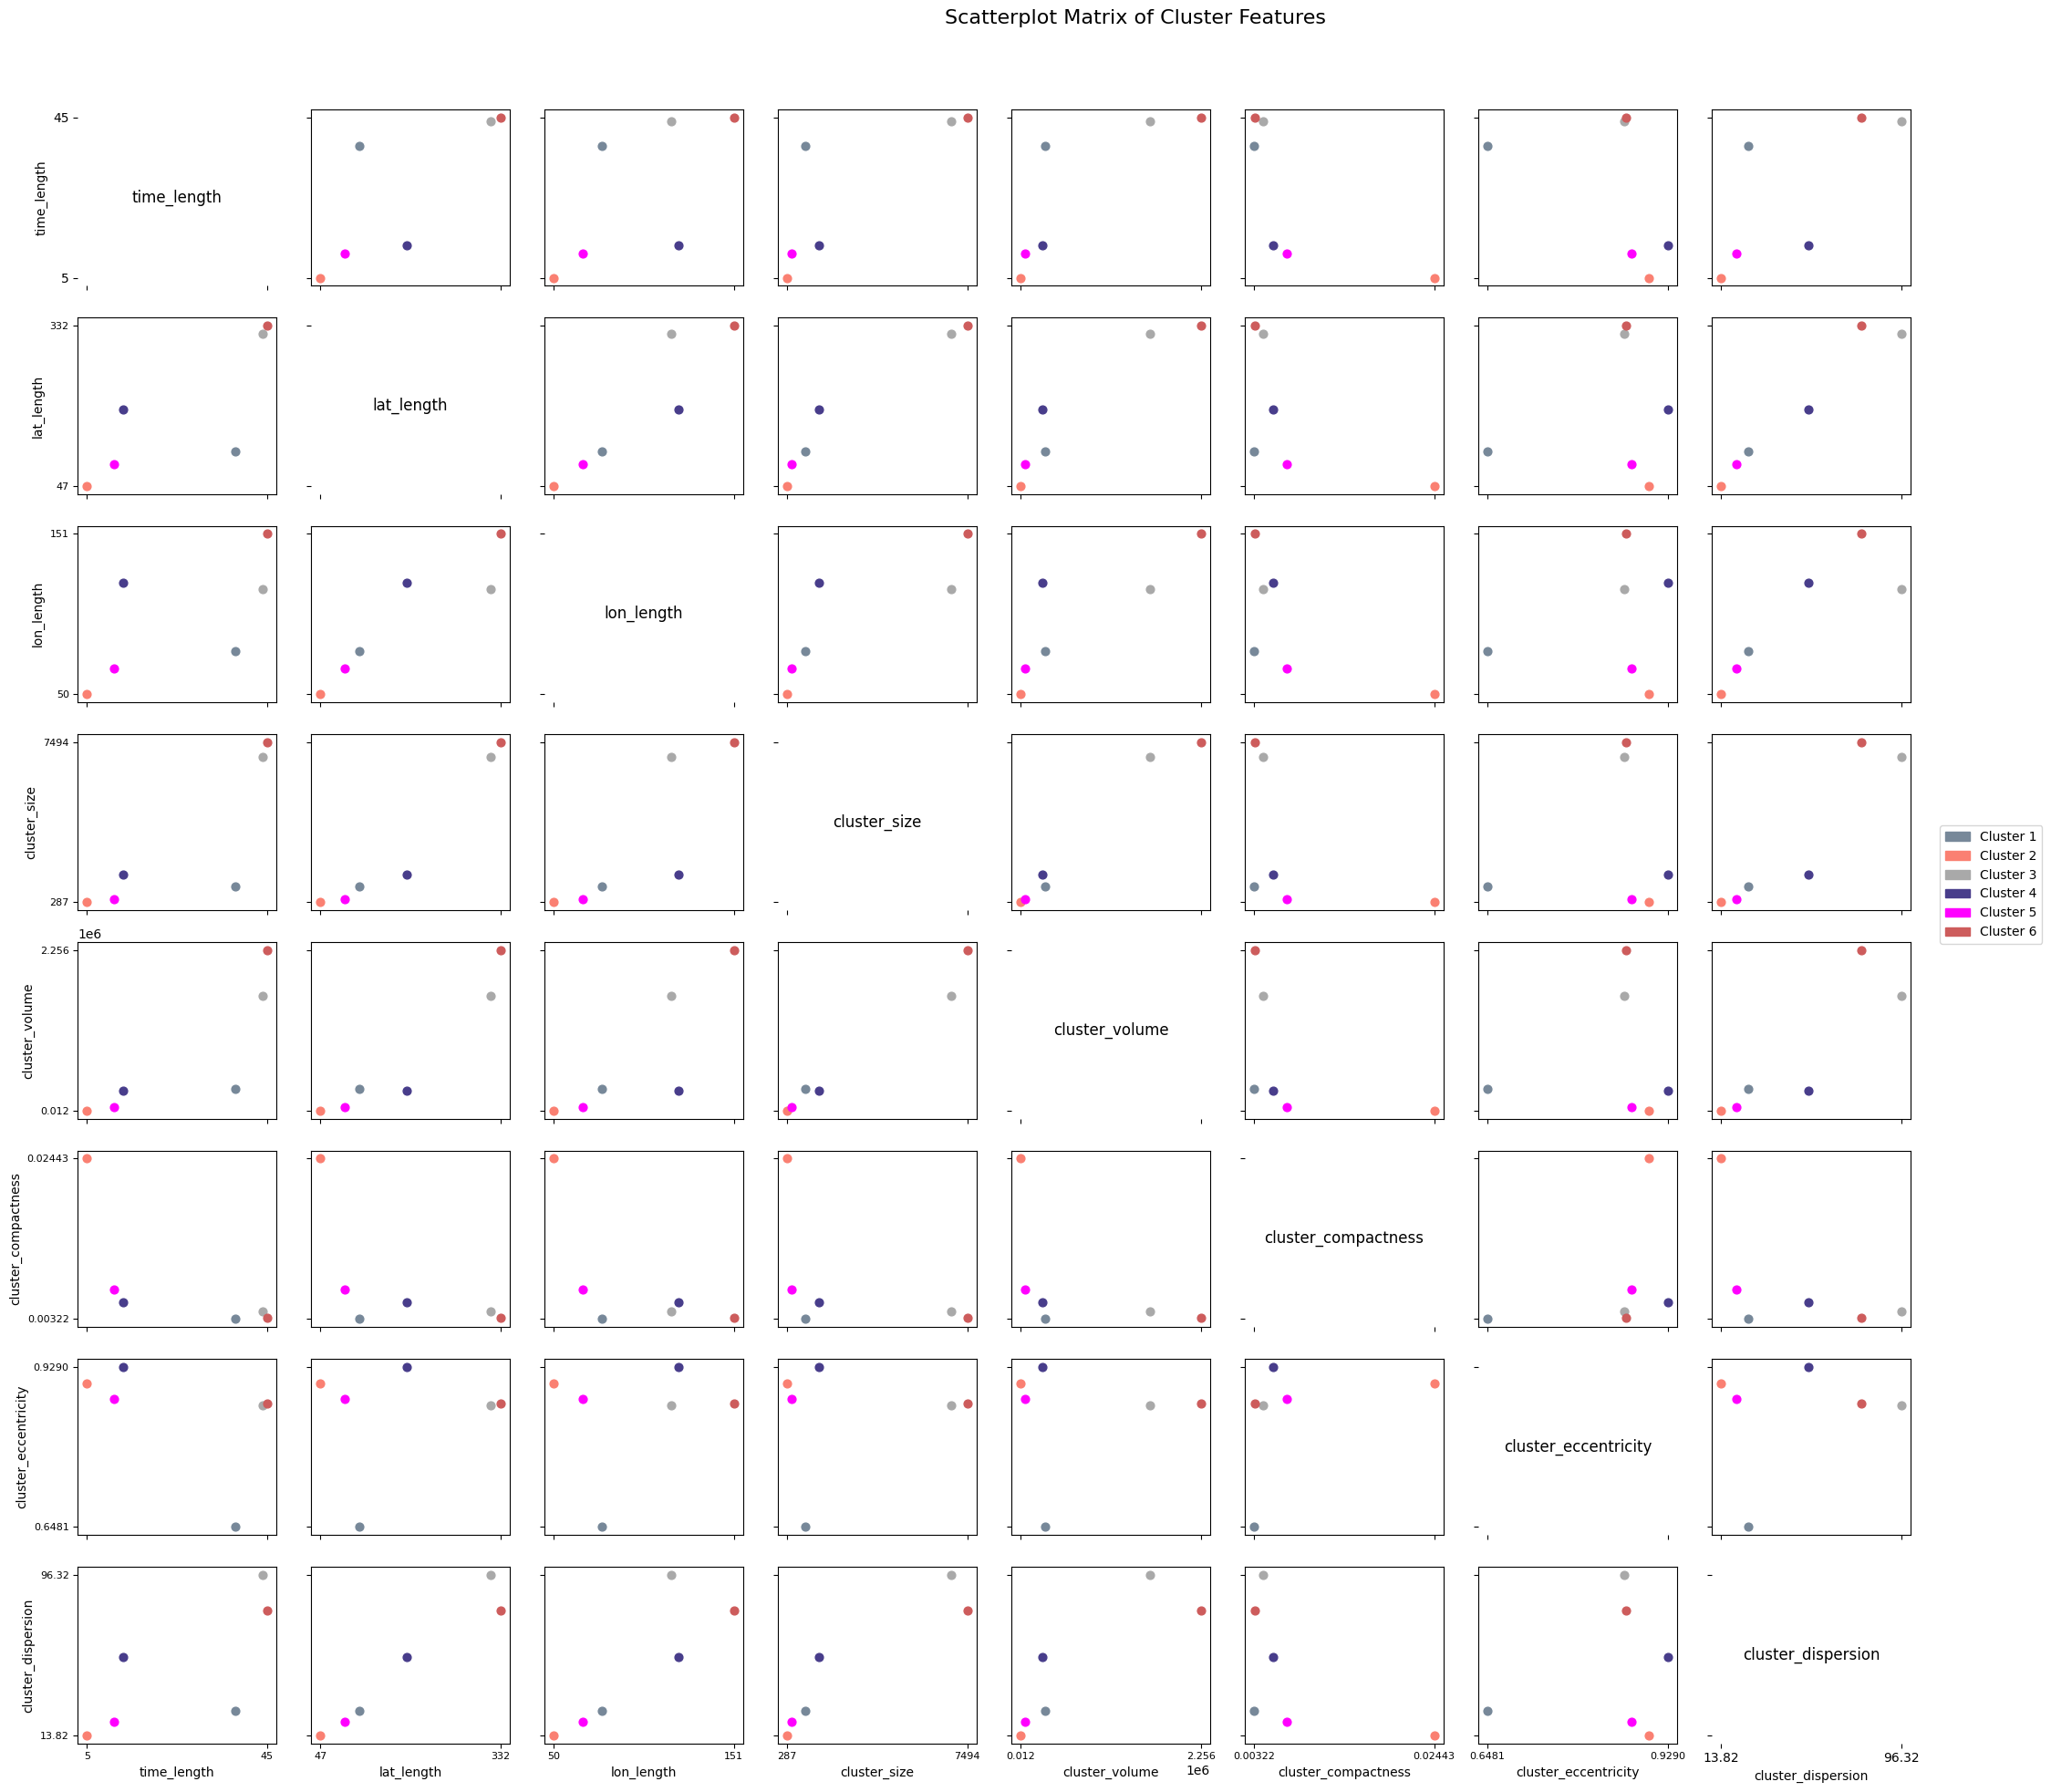




Experiment: (2) Base Full Period
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_500_1.pkl
   time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1          4.0        66.0        70.0        1465.0         18480.0             0.079275              0.942857           18.549296
2          4.0       135.0        91.0        3853.0         49140.0             0.078409              0.970370           33.074977
3          1.0        31.0        29.0         510.0           899.0             0.567297              0.967742            9.158521
4          1.0        73.0        42.0        1007.0          3066.0             0.328441              0.986301           20.384890
5          1.0        33.0        50.0         531.0          1650.0             0.321818              0.980000           11.349173
6          1.0        28.0        44.0         315.0          1232.0             0.25568

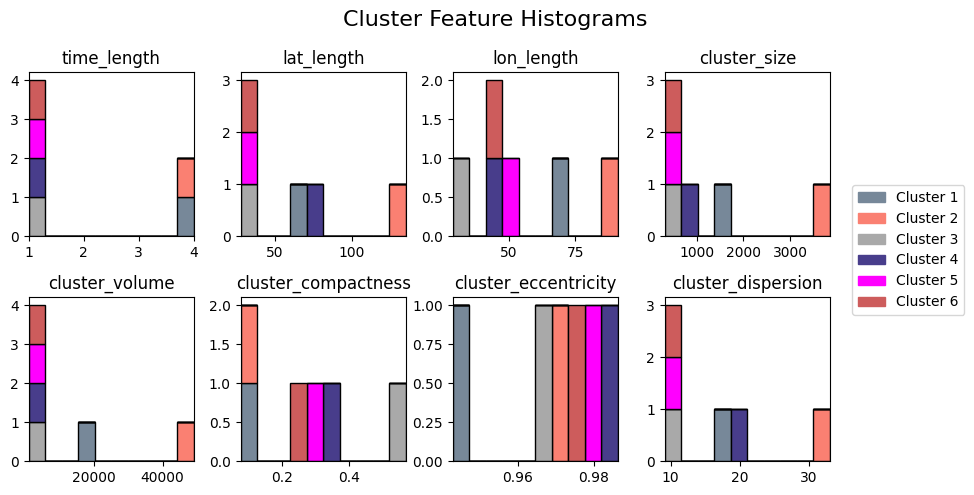

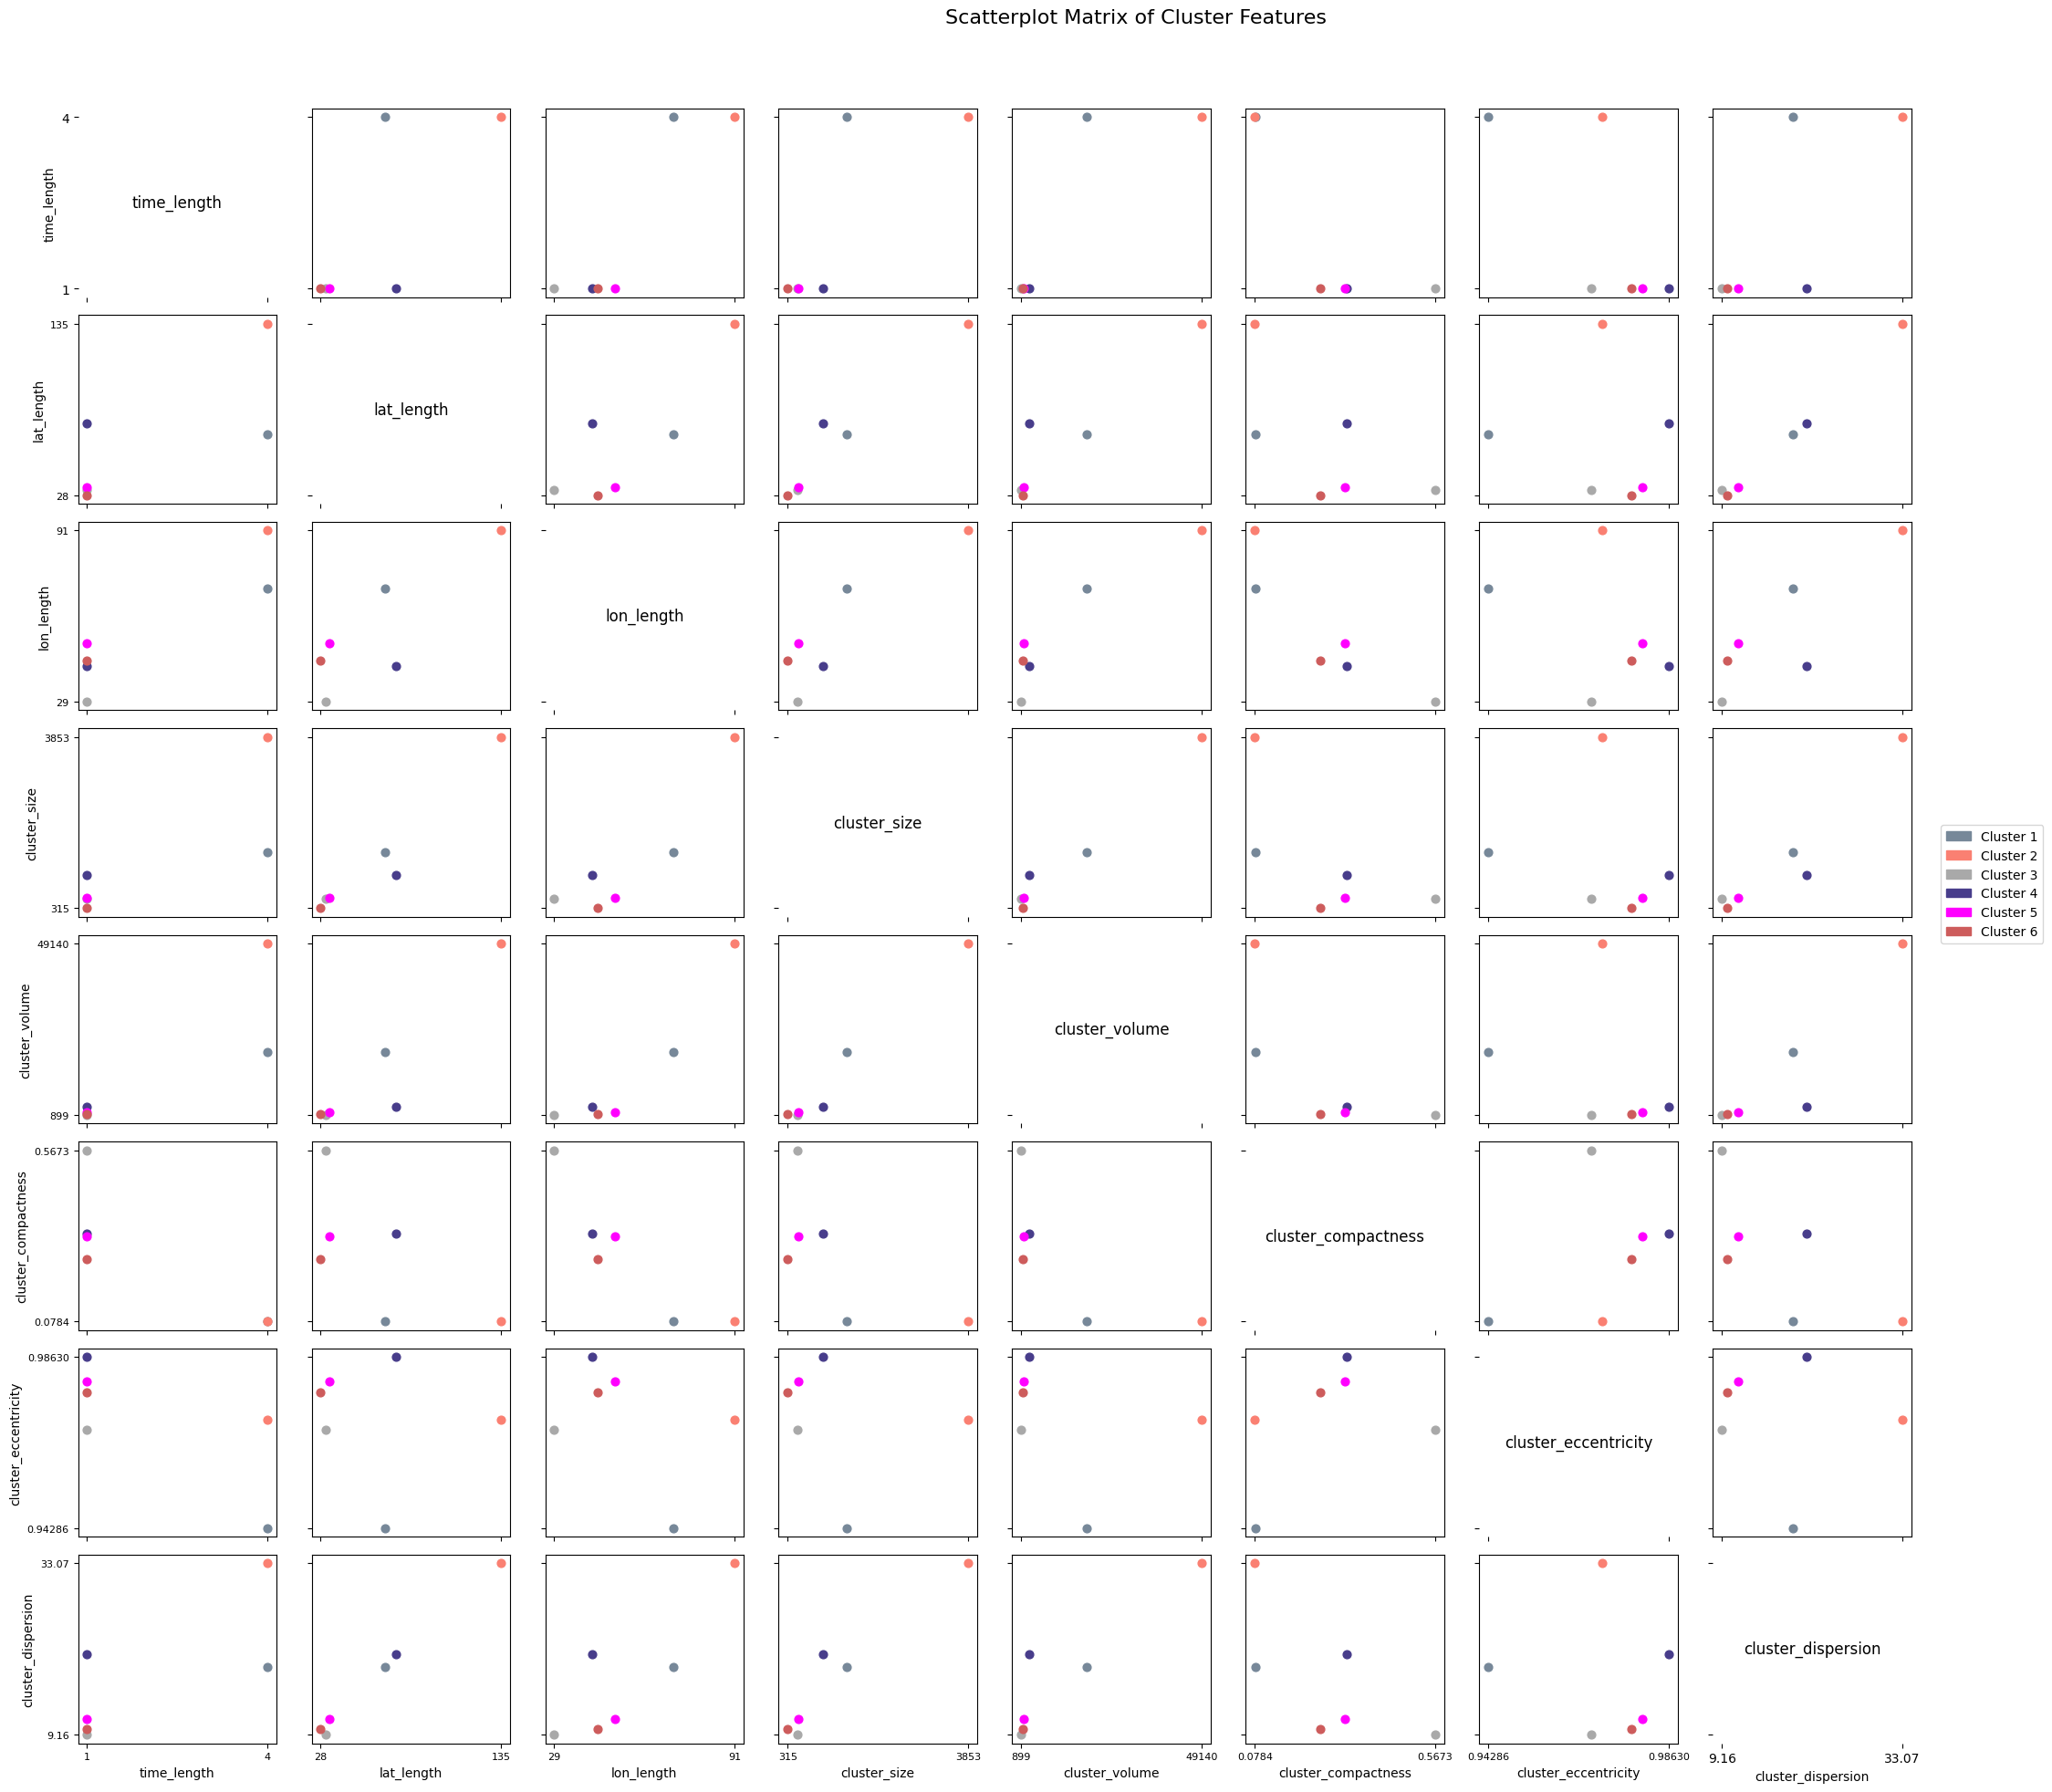




Experiment: (2) Smaller Min Neighbors
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_250_1.pkl
    time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1           2.0        45.0        55.0         453.0          4950.0             0.091515              0.963636           14.491013
2           1.0        20.0        28.0         216.0           560.0             0.385714              0.964286            7.767735
3           4.0        70.0        75.0        1571.0         21000.0             0.074810              0.946667           18.514243
4           1.0        34.0        16.0         213.0           544.0             0.391544              0.970588            9.192135
5           3.0        68.0        35.0         356.0          7140.0             0.049860              0.955882           14.484588
6           5.0       135.0        91.0        3887.0         61425.0        

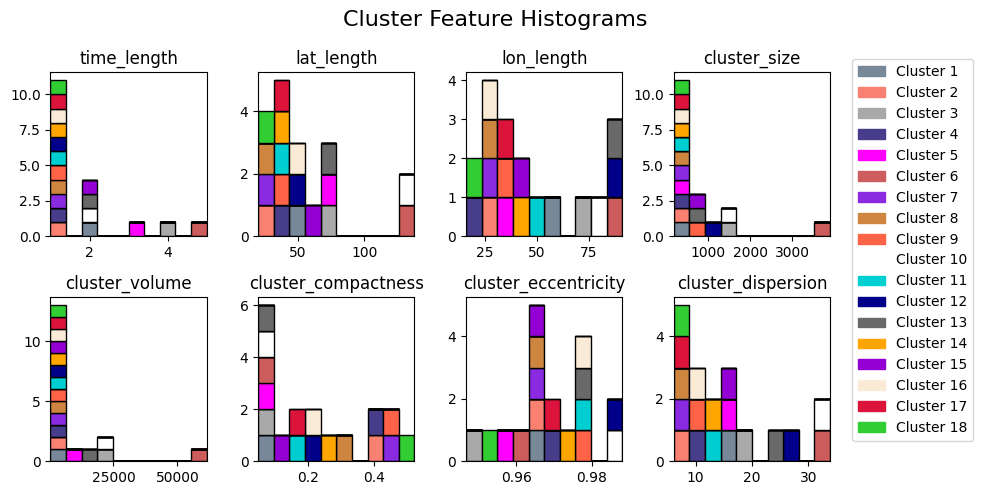

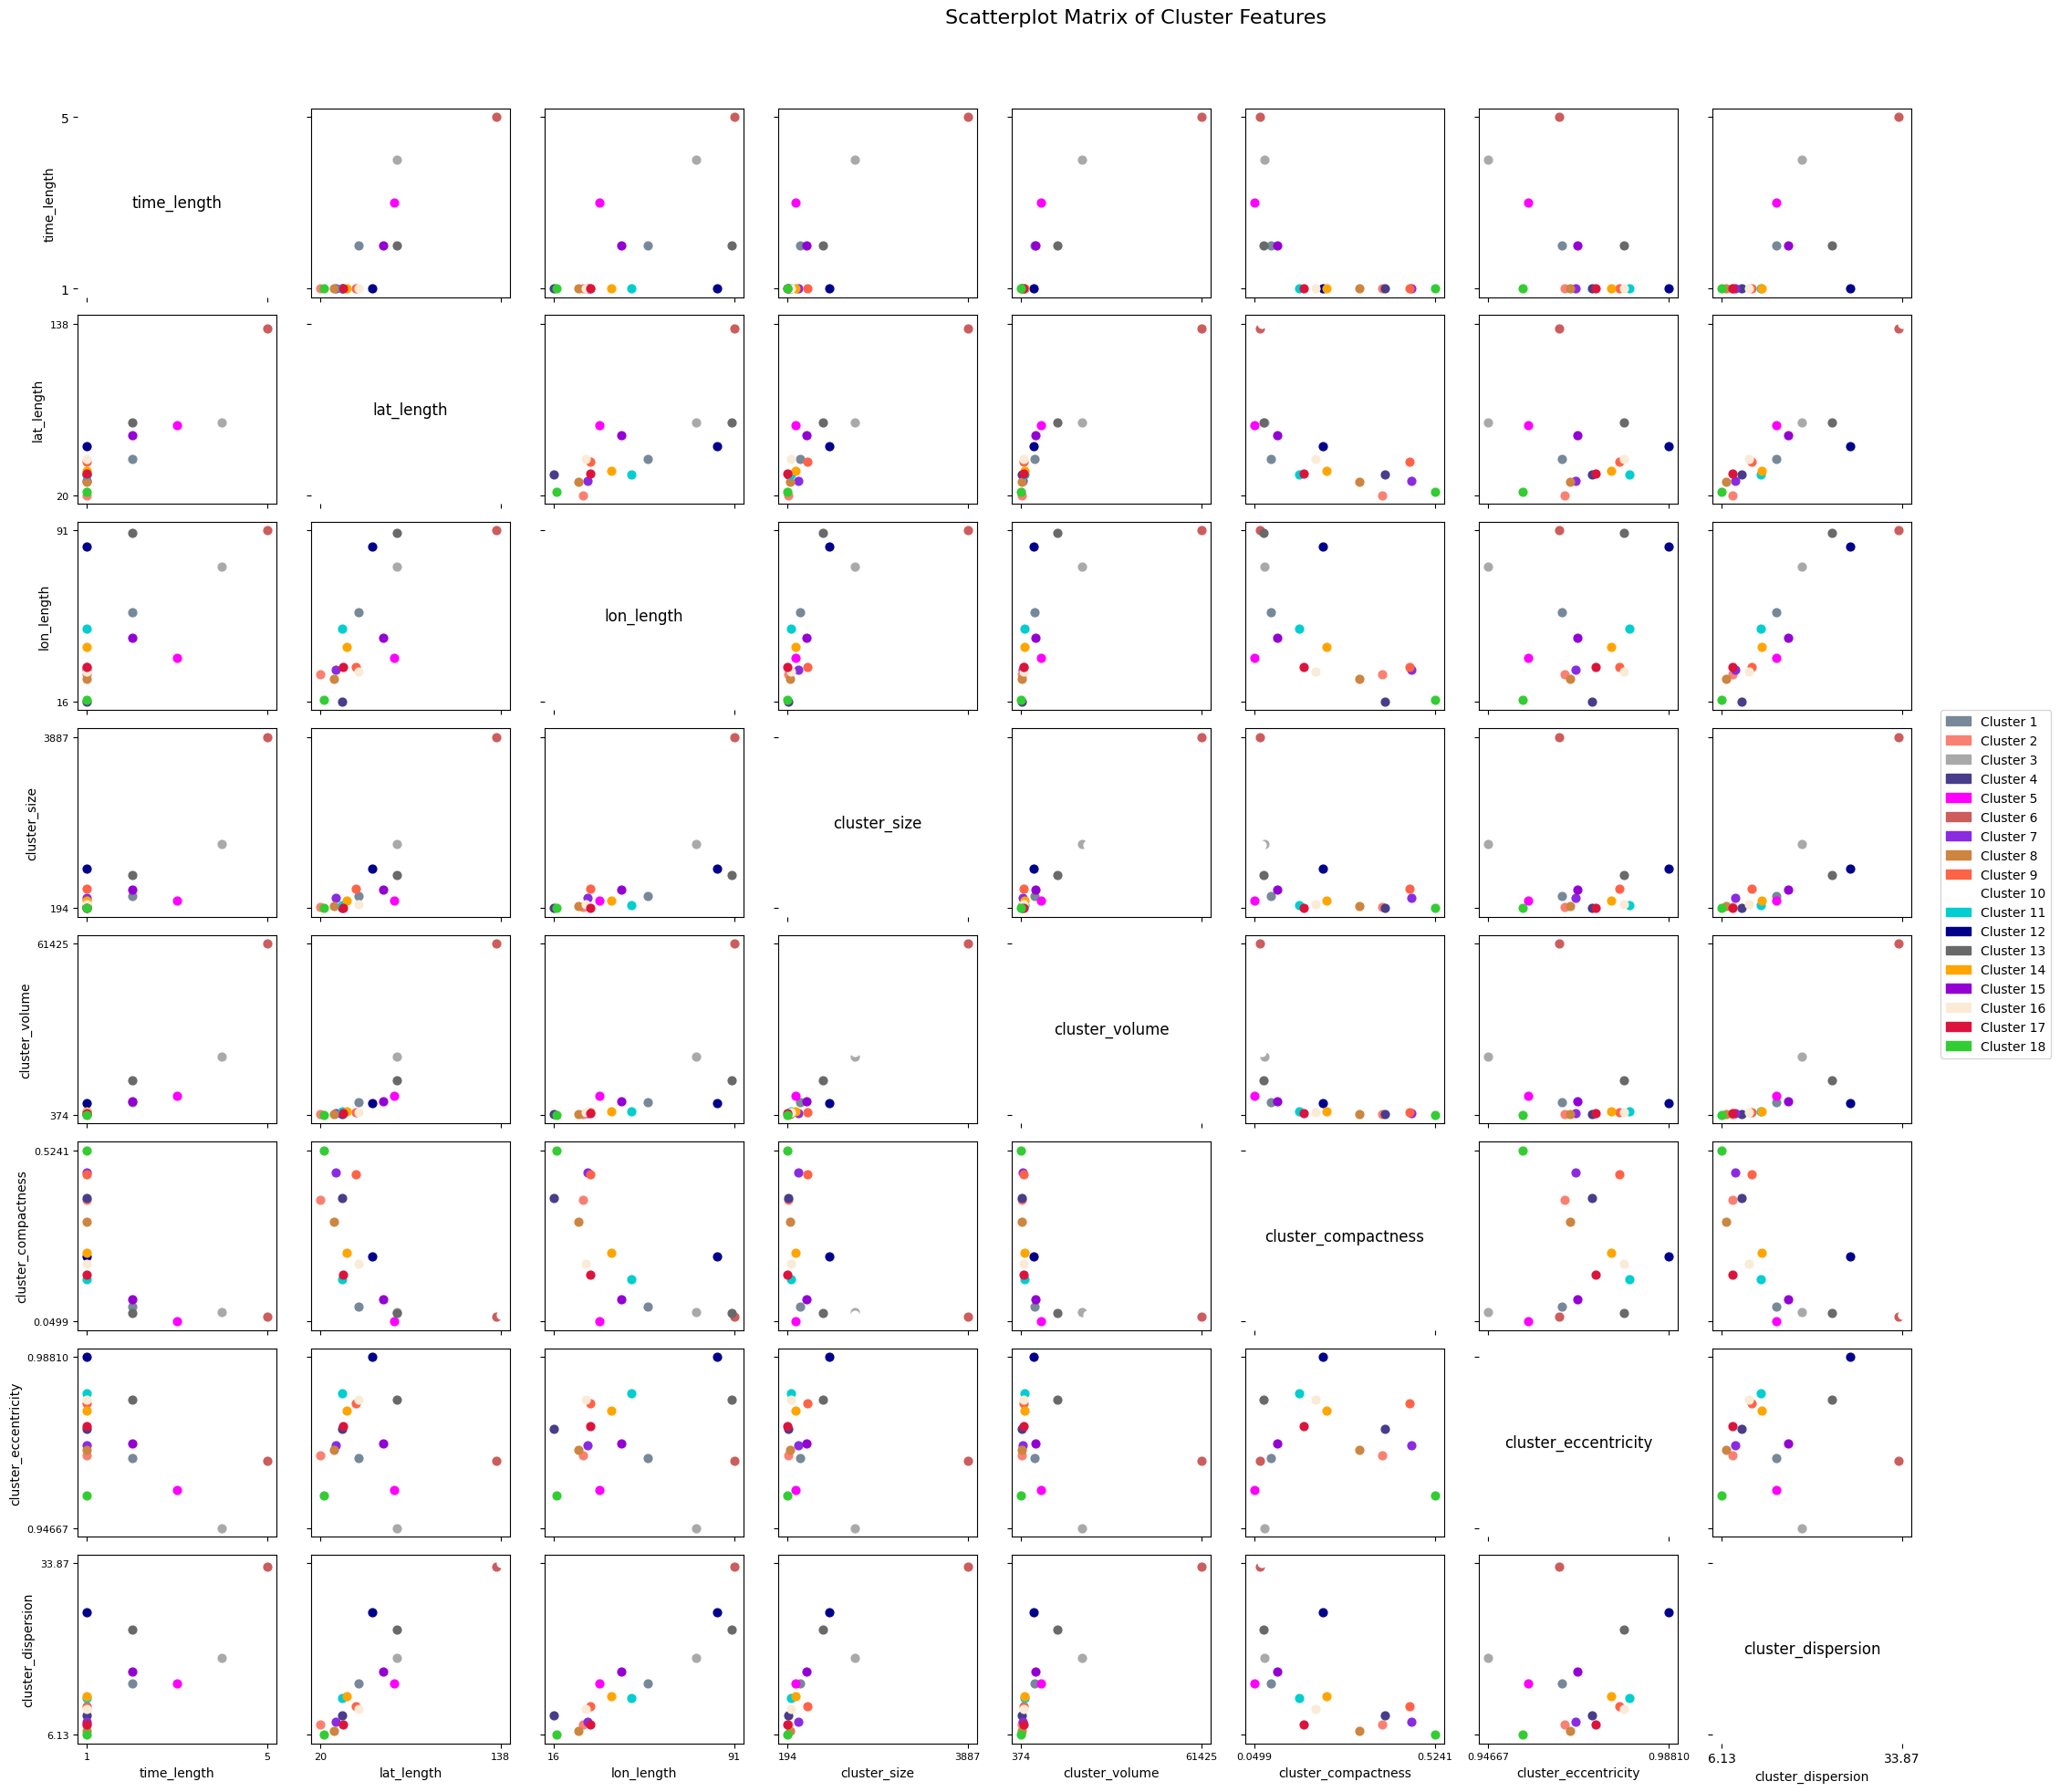




Experiment: (2) Larger Min Neighbors
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_750_1.pkl
   time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1          2.0        41.0        42.0         181.0          3444.0             0.052555              0.952381           13.430173
2          4.0       130.0        90.0        3727.0         46800.0             0.079637              0.969231           32.383041


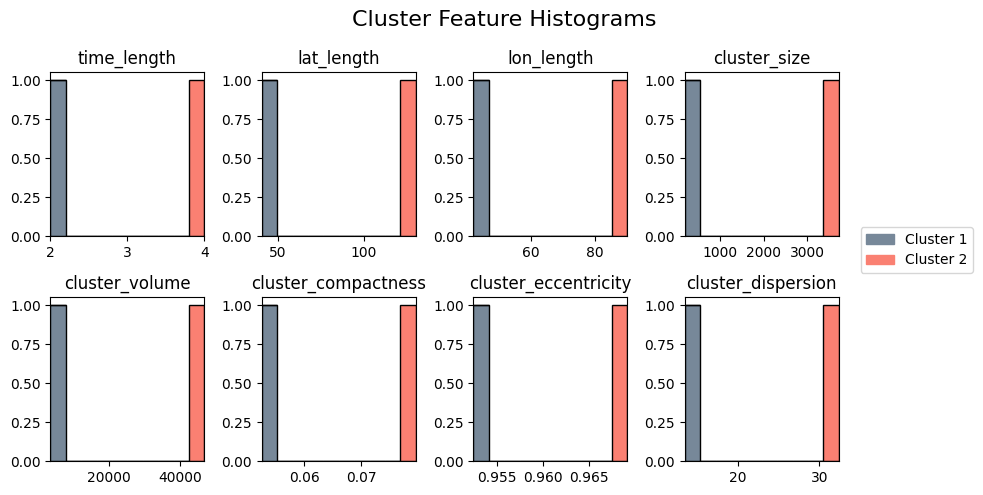

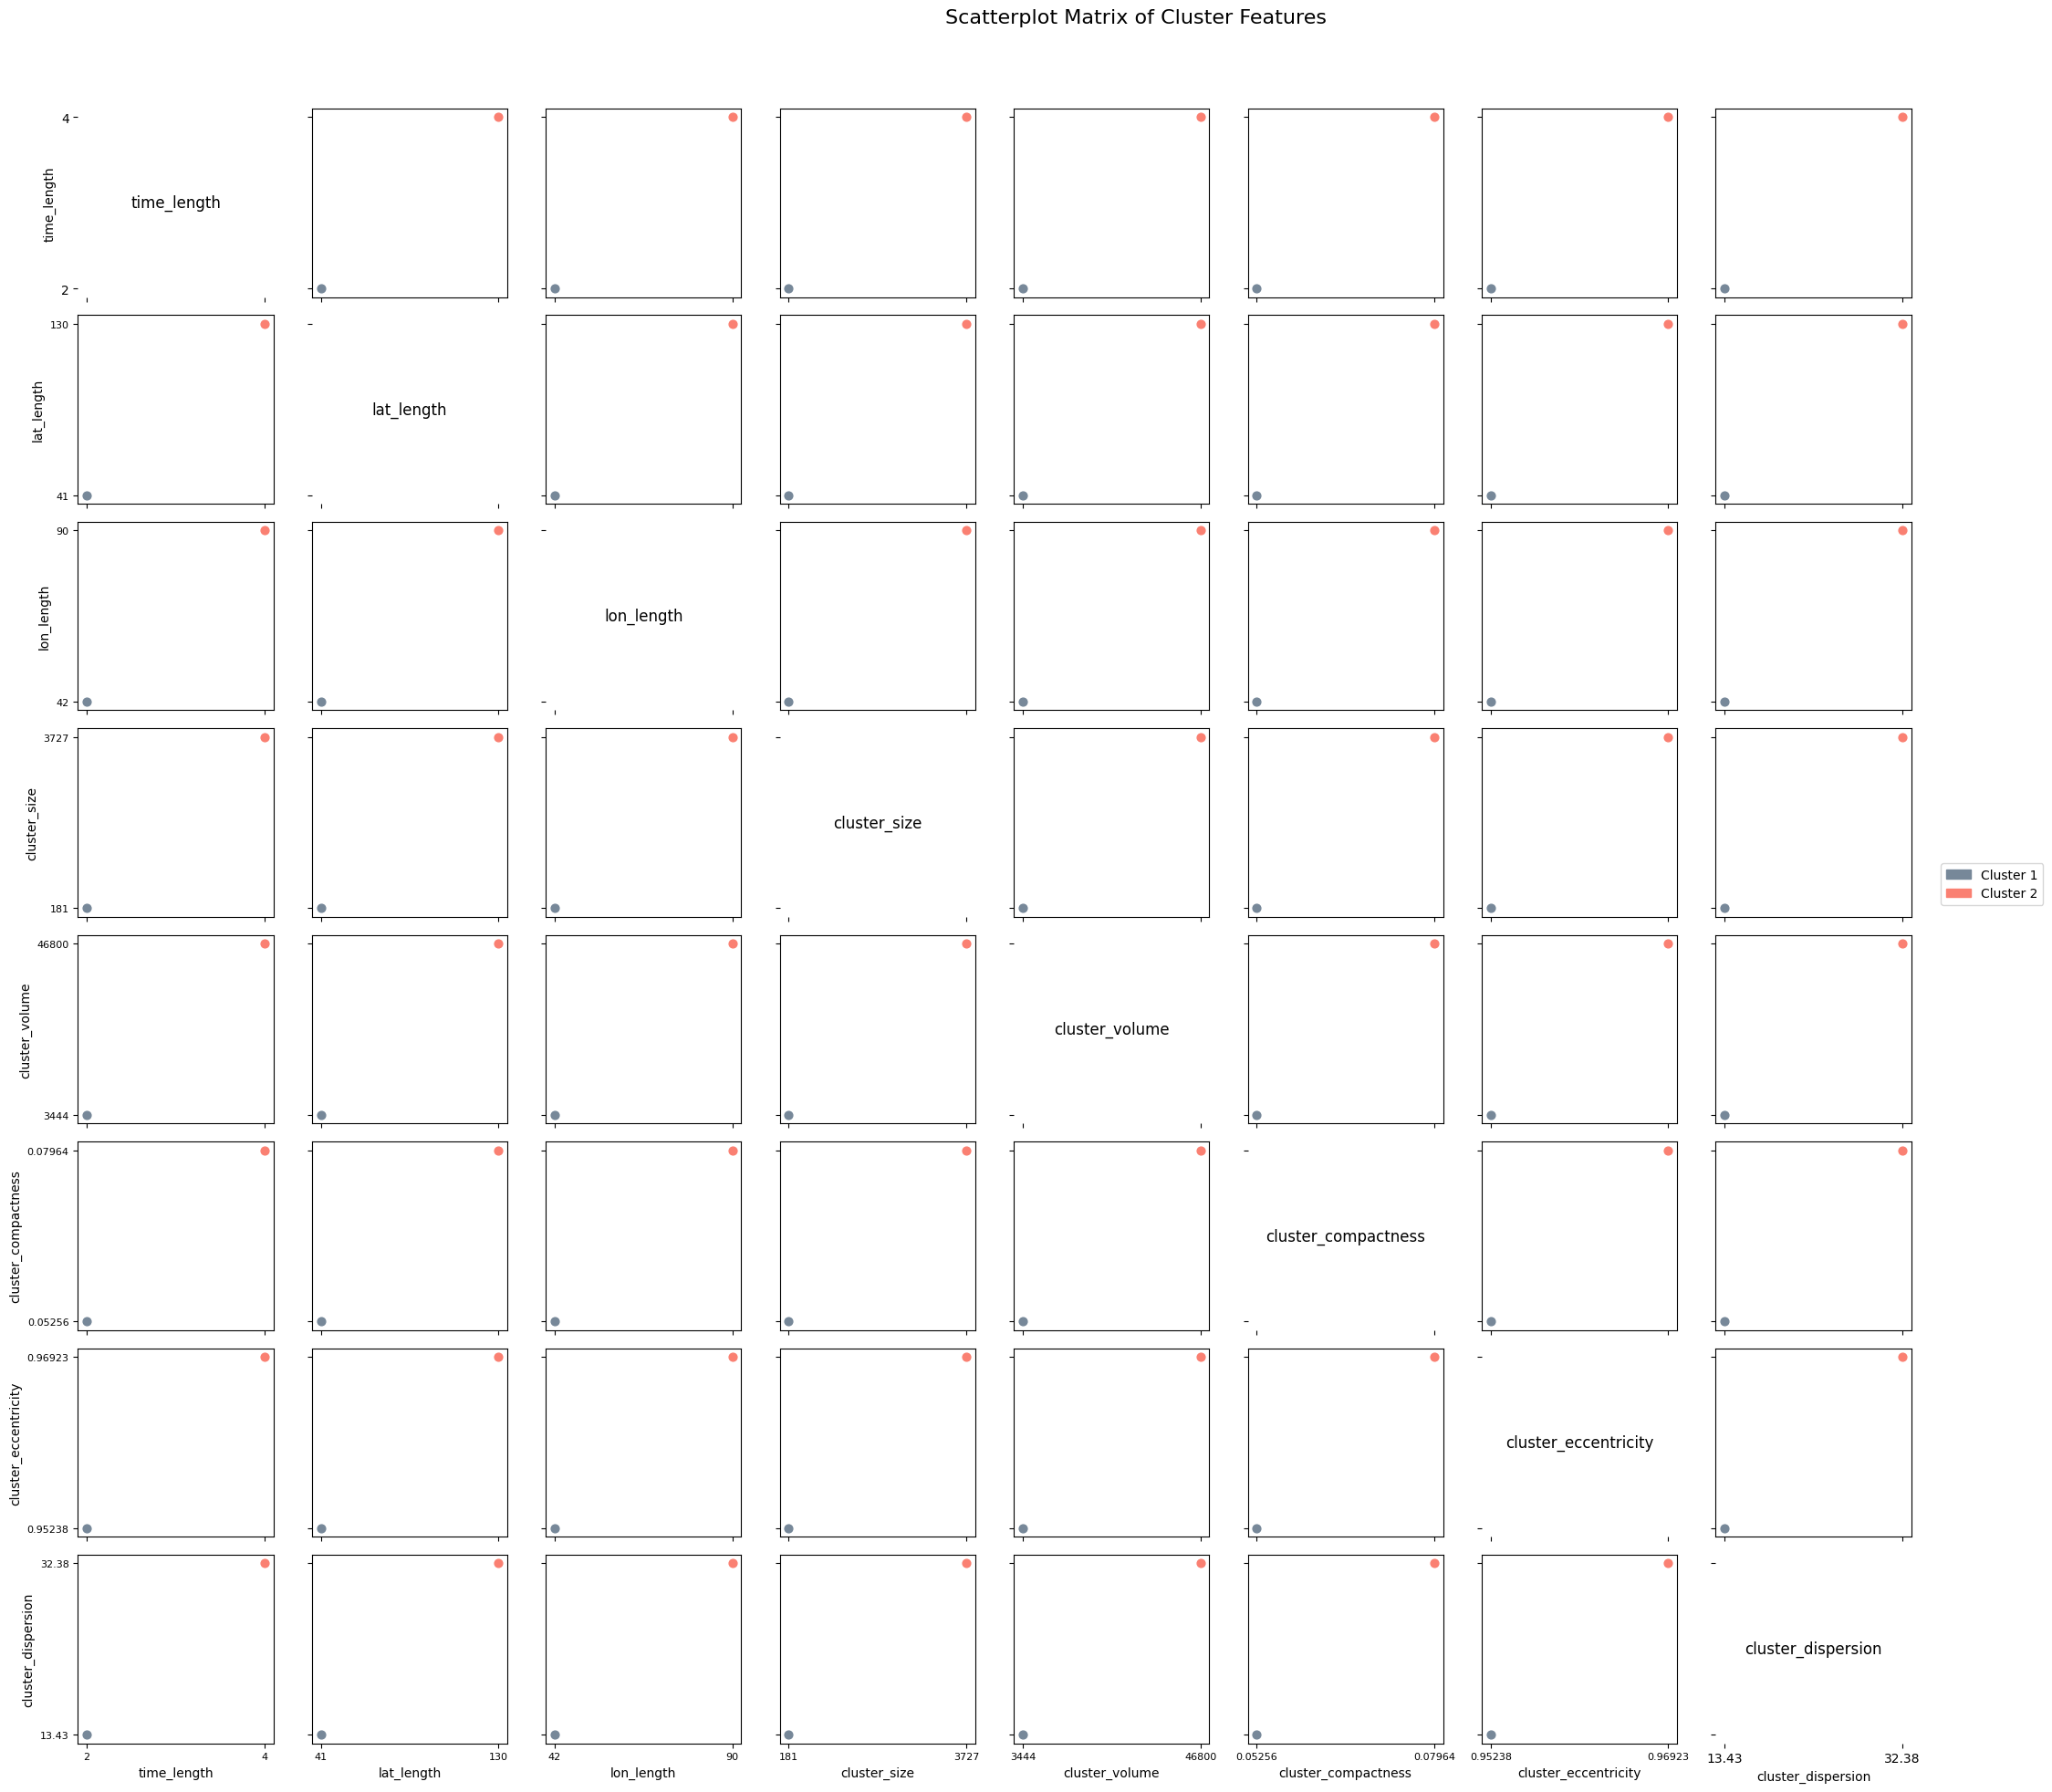




Experiment: (2) Much Larger Min Neighbors
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_20_20_1000_1.pkl
   time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1          3.0       115.0        74.0        3249.0         25530.0             0.127262              0.973913           29.268554


c:\Users\sebas\TFM-2025-SST\ocean_tools\visualization\feature_plots.py:64: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(min_val, max_val)


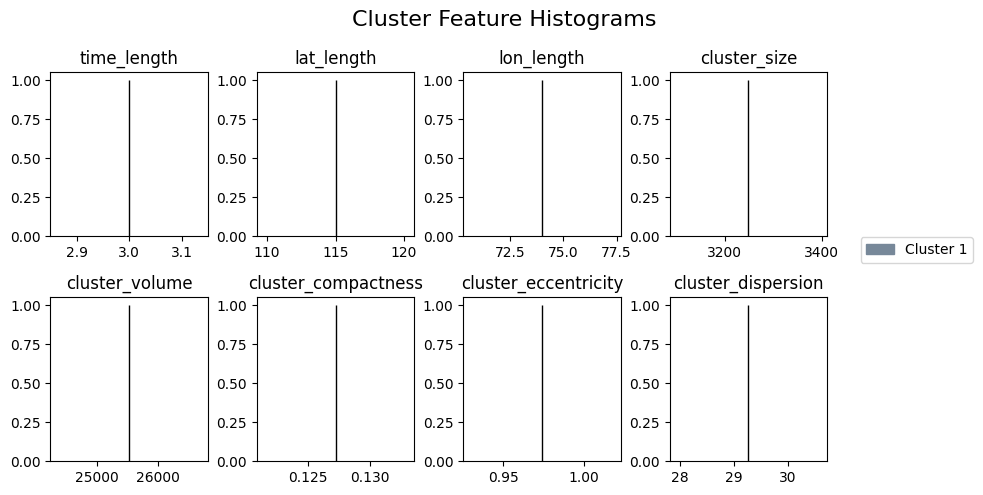

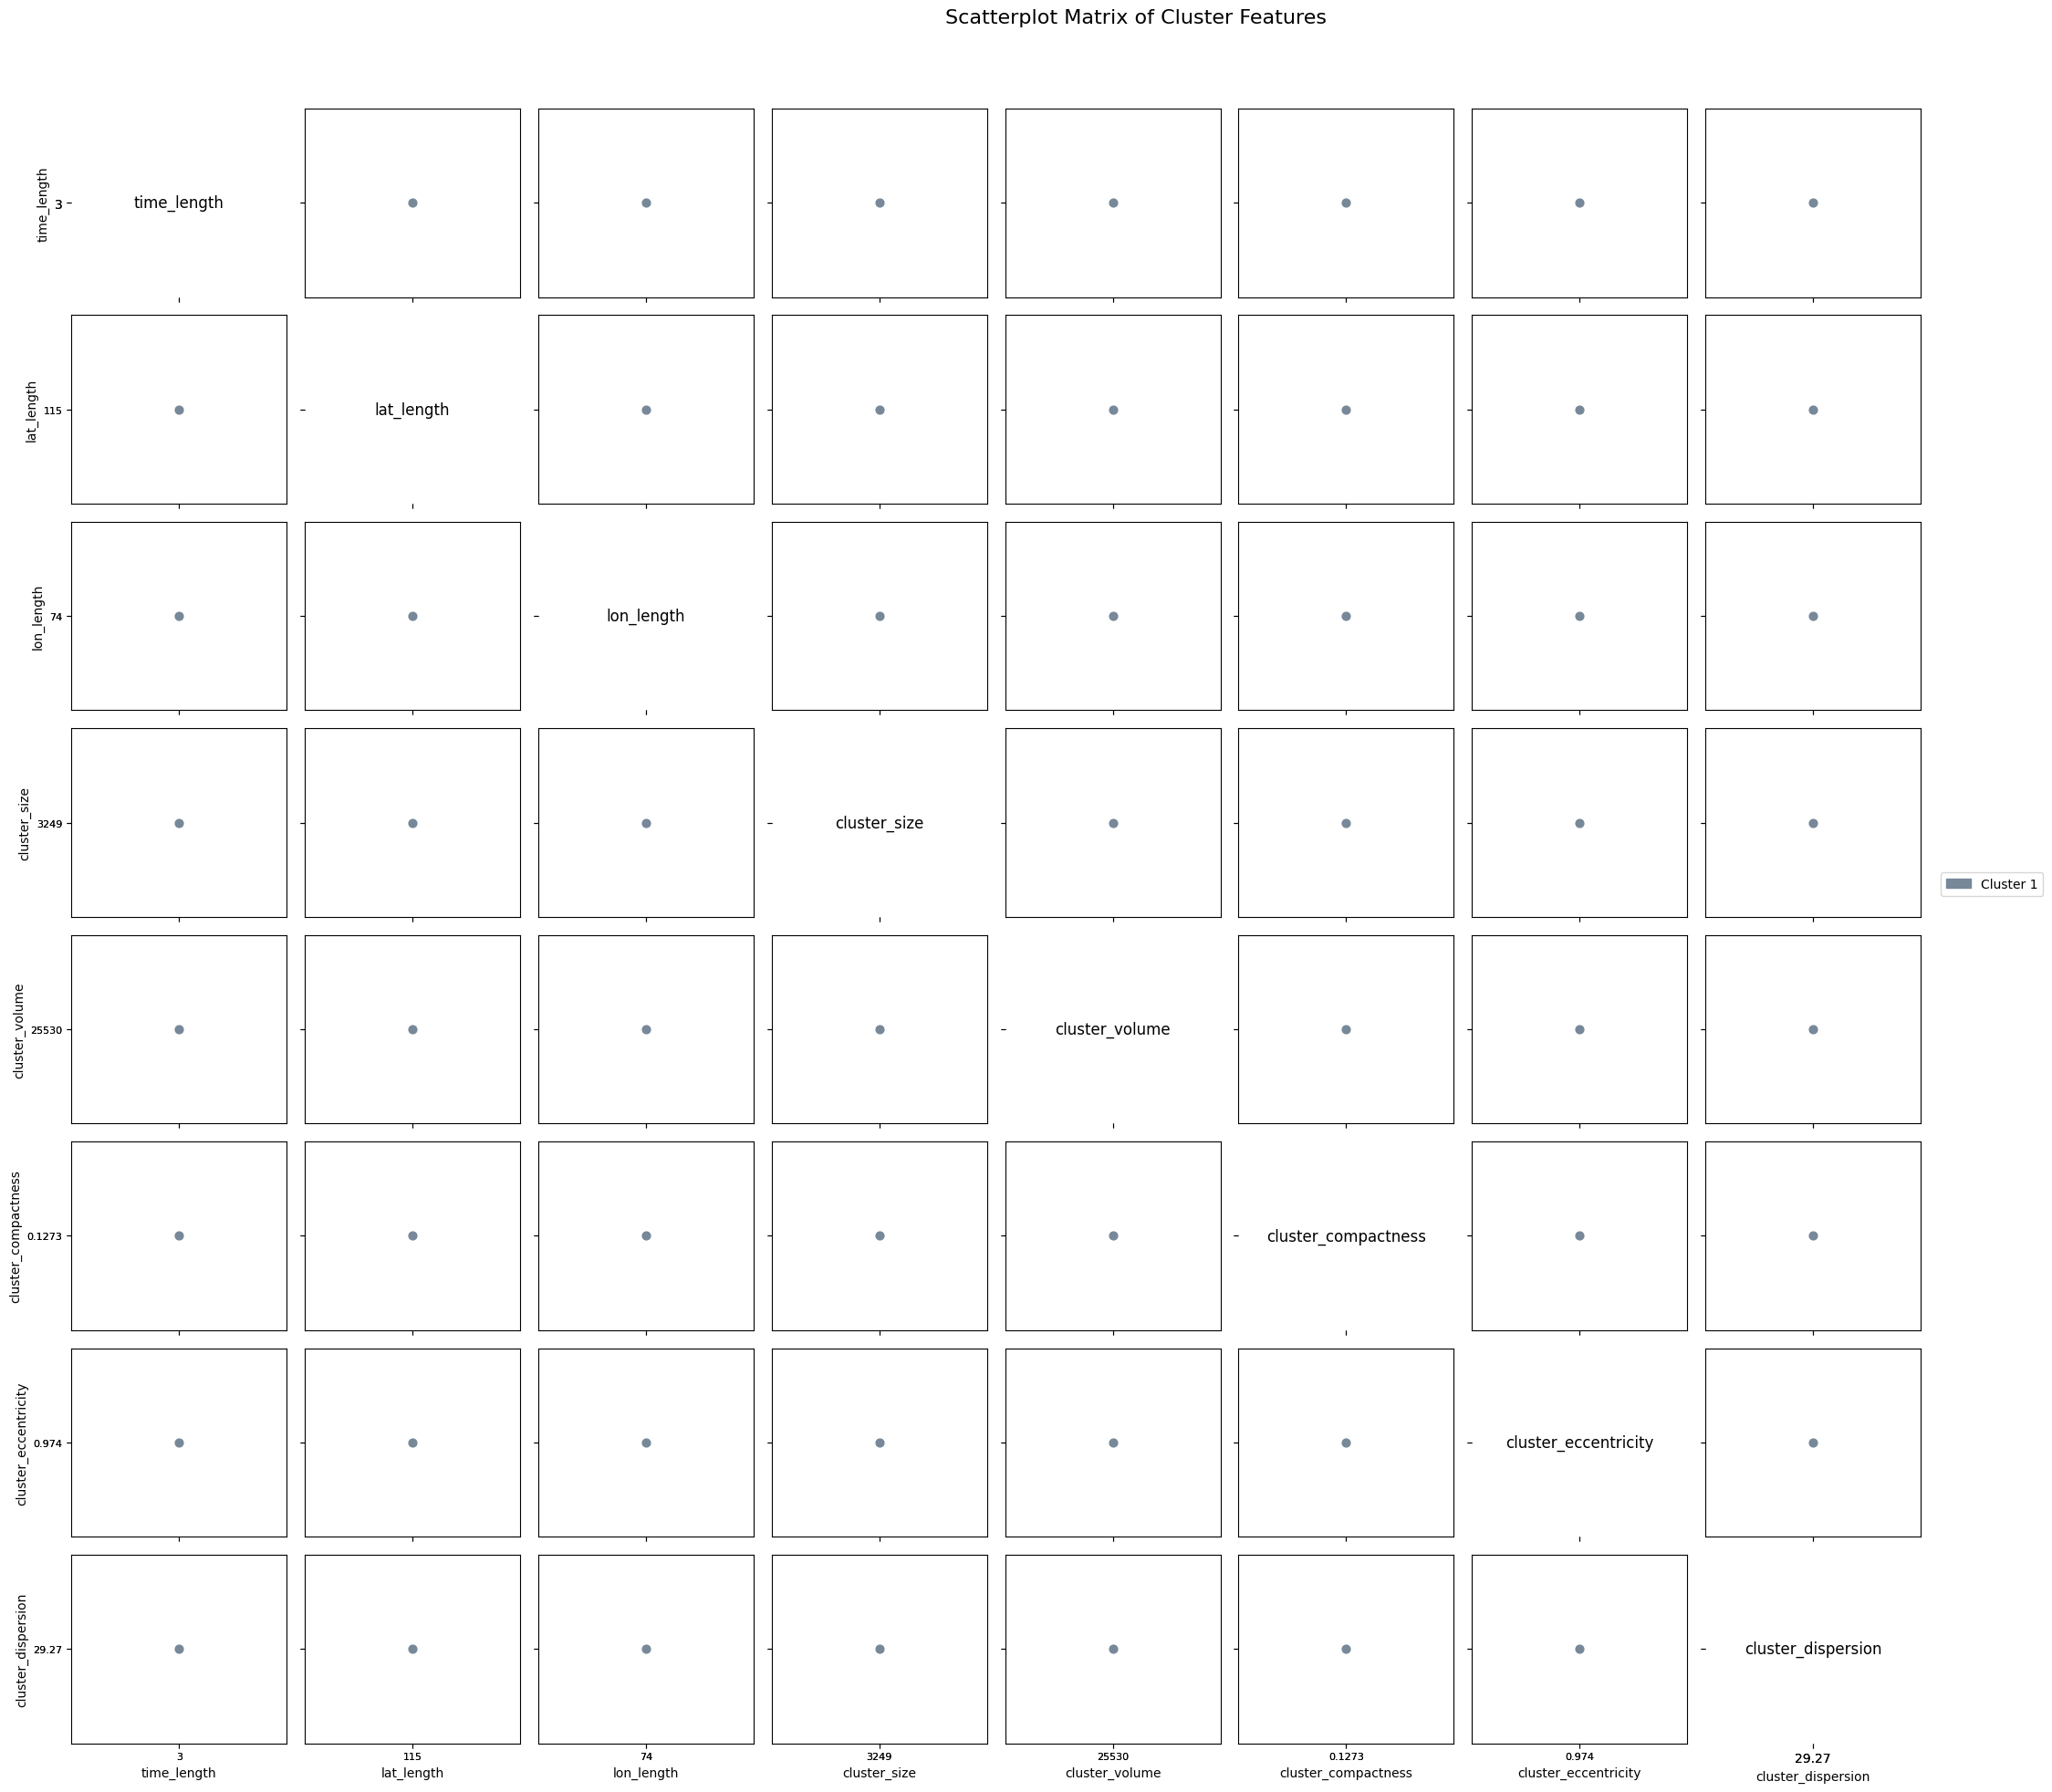




Experiment: (2) Smaller Geo Eps
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_10_10_500_1.pkl
   time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1          2.0        23.0        27.0         442.0          1242.0             0.355878              0.925926            7.417121


c:\Users\sebas\TFM-2025-SST\ocean_tools\visualization\feature_plots.py:64: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(min_val, max_val)


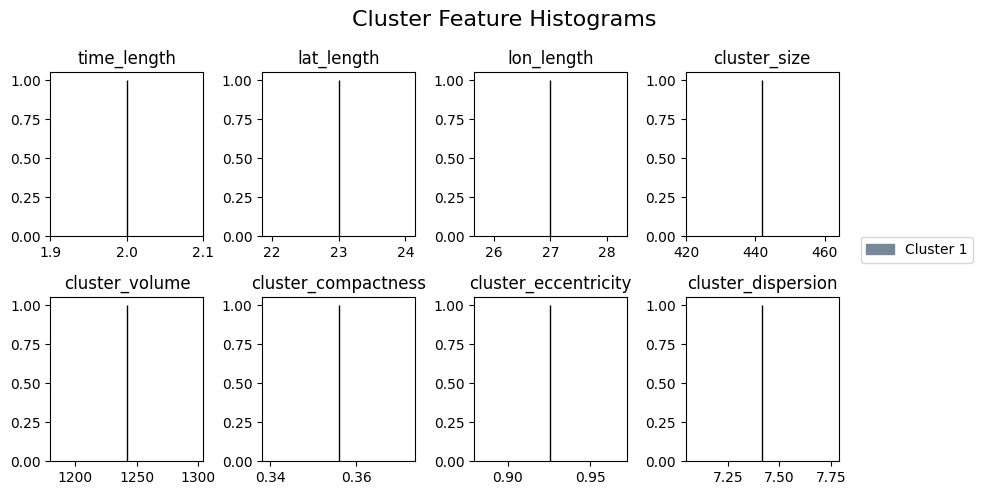

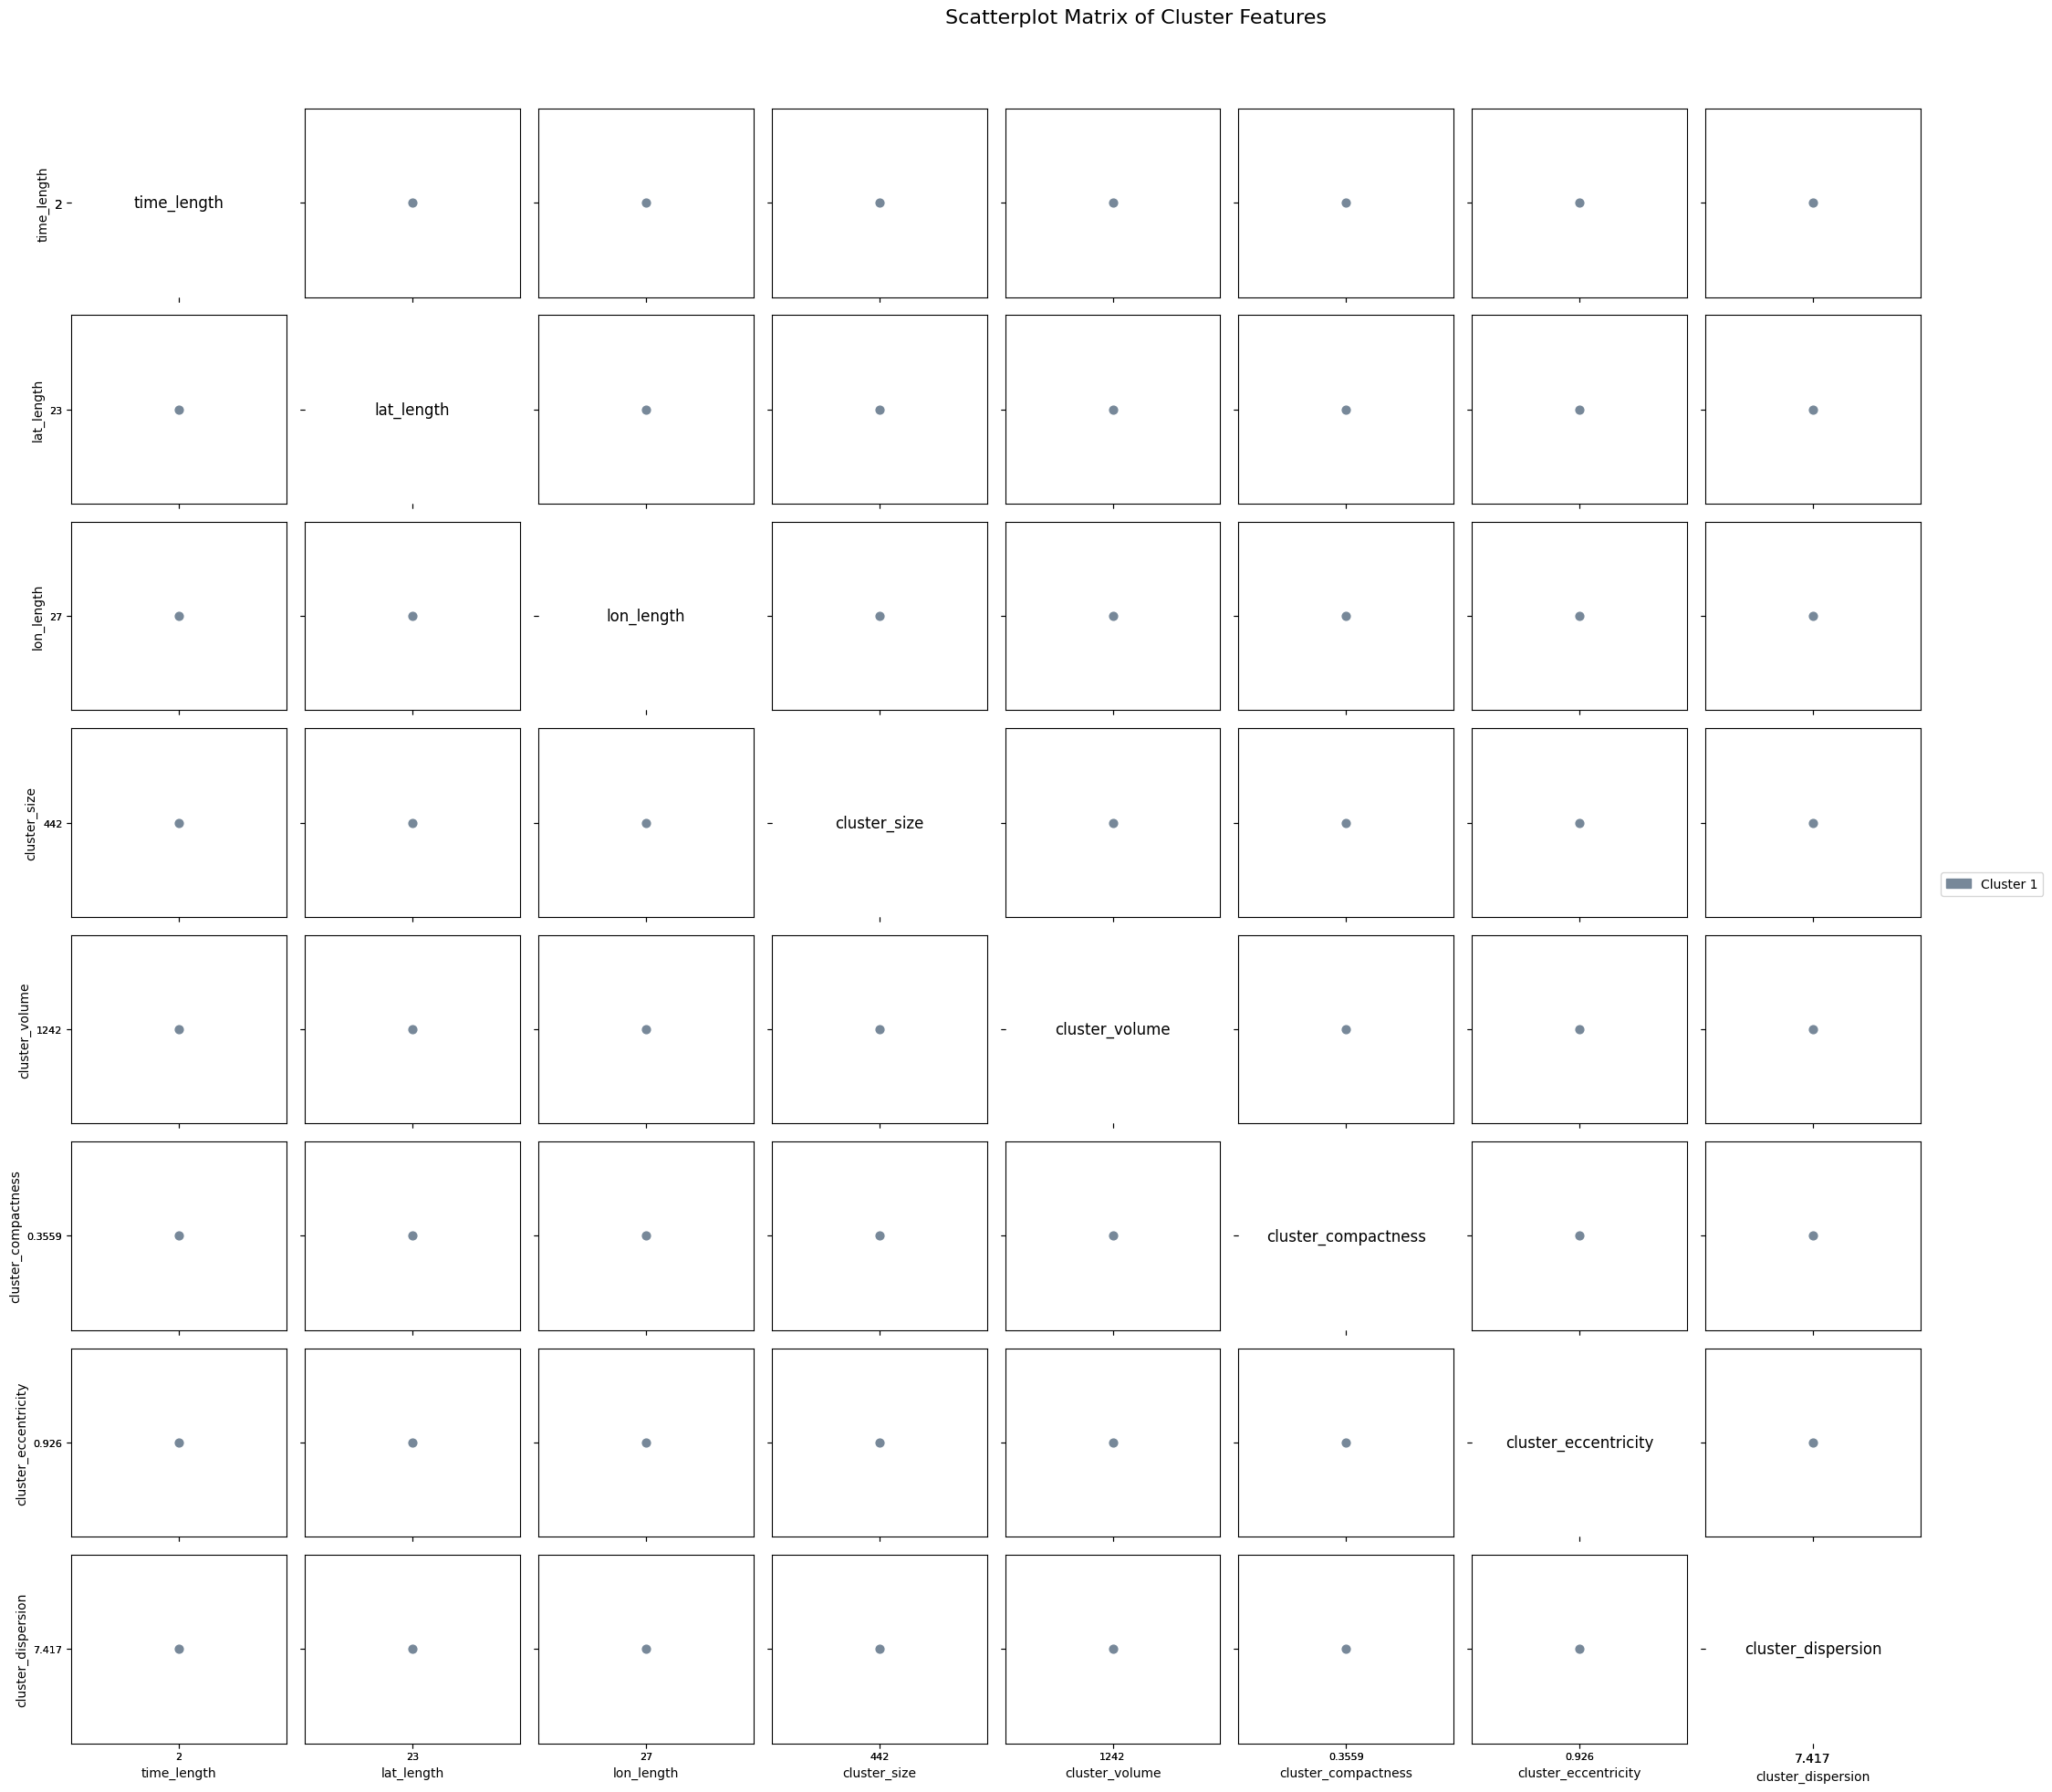




Experiment: (2) Larger Geo Eps
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_1_50_50_500_1.pkl
    time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1           2.0        60.0        71.0         502.0          8520.0             0.058920              0.971831           16.343003
2           6.0       146.0        87.0        1969.0         76212.0             0.025836              0.958904           28.901063
3           2.0       141.0        37.0         482.0         10434.0             0.046195              0.985816           29.254157
4           6.0       190.0       116.0        4017.0        132240.0             0.030377              0.968421           34.924037
5           1.0        70.0        97.0         515.0          6790.0             0.075847              0.989691           19.577732
6           1.0        53.0        31.0         621.0          1643.0             0.

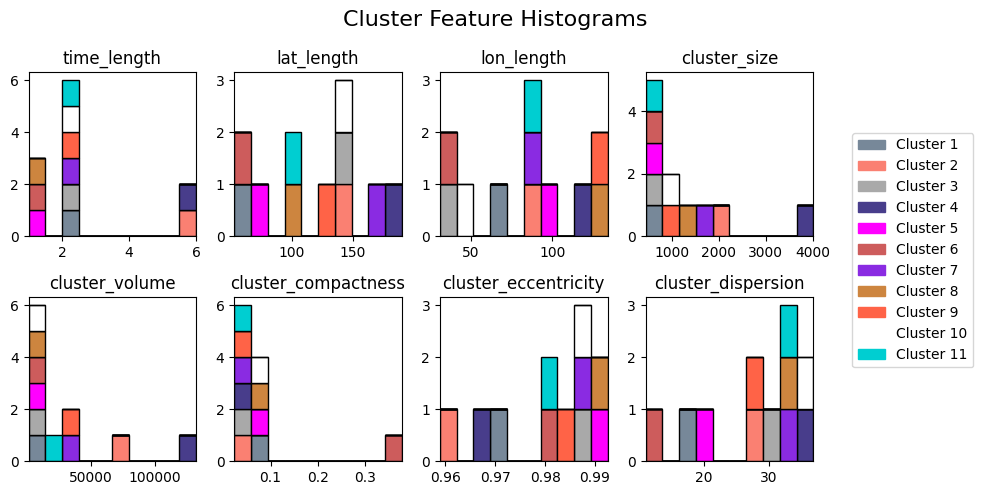

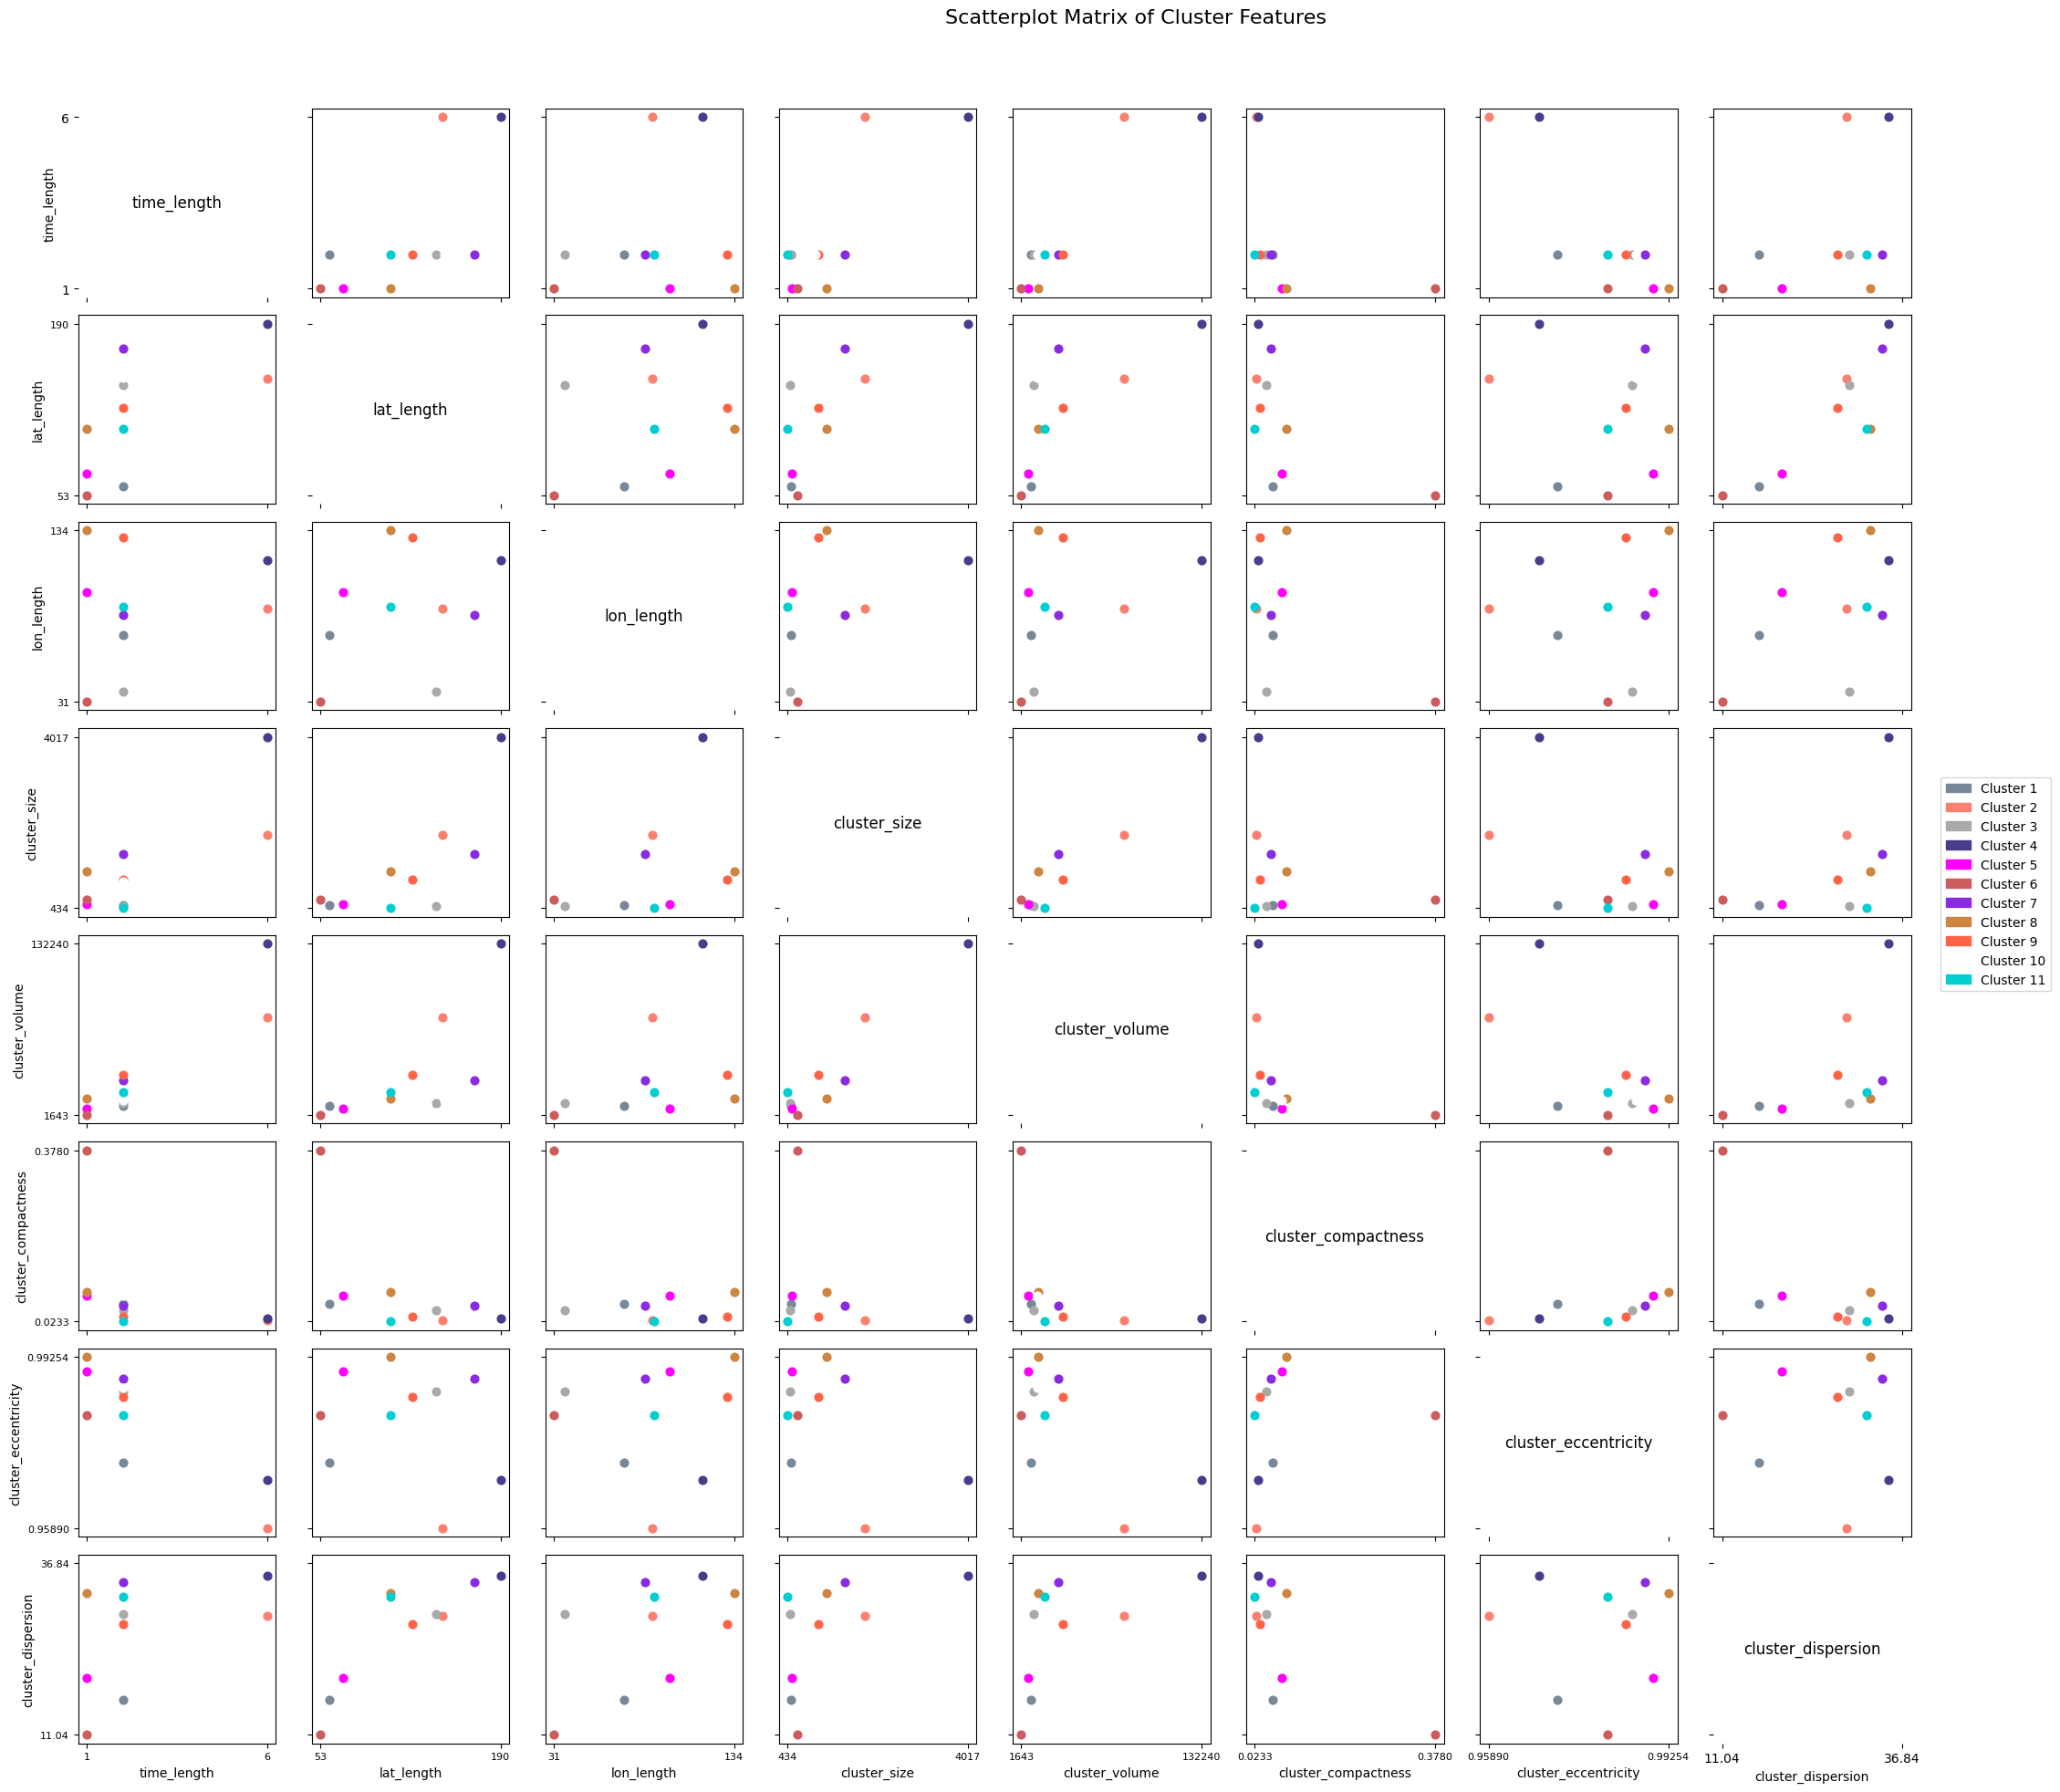




Experiment: (2) Larger Time Eps
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_2_20_20_500_1.pkl
   time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1          4.0        75.0        83.0        1615.0         24900.0             0.064859              0.951807           19.427631
2          6.0       143.0        91.0        3962.0         78078.0             0.050744              0.958042           33.963862
3          3.0        55.0        32.0         900.0          5280.0             0.170455              0.945455           11.304168
4          1.0        73.0        42.0        1007.0          3066.0             0.328441              0.986301           20.384890
5          1.0        33.0        50.0         531.0          1650.0             0.321818              0.980000           11.349173
6          1.0        28.0        44.0         315.0          1232.0             0.255682

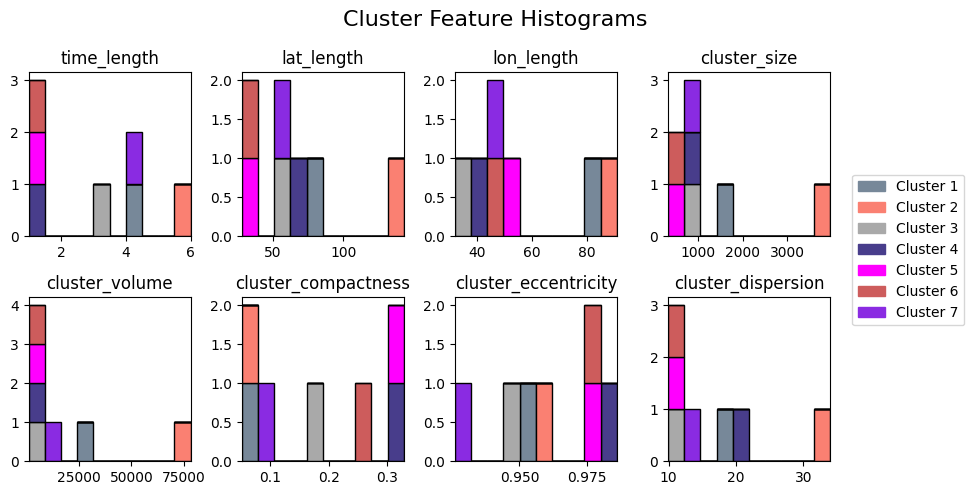

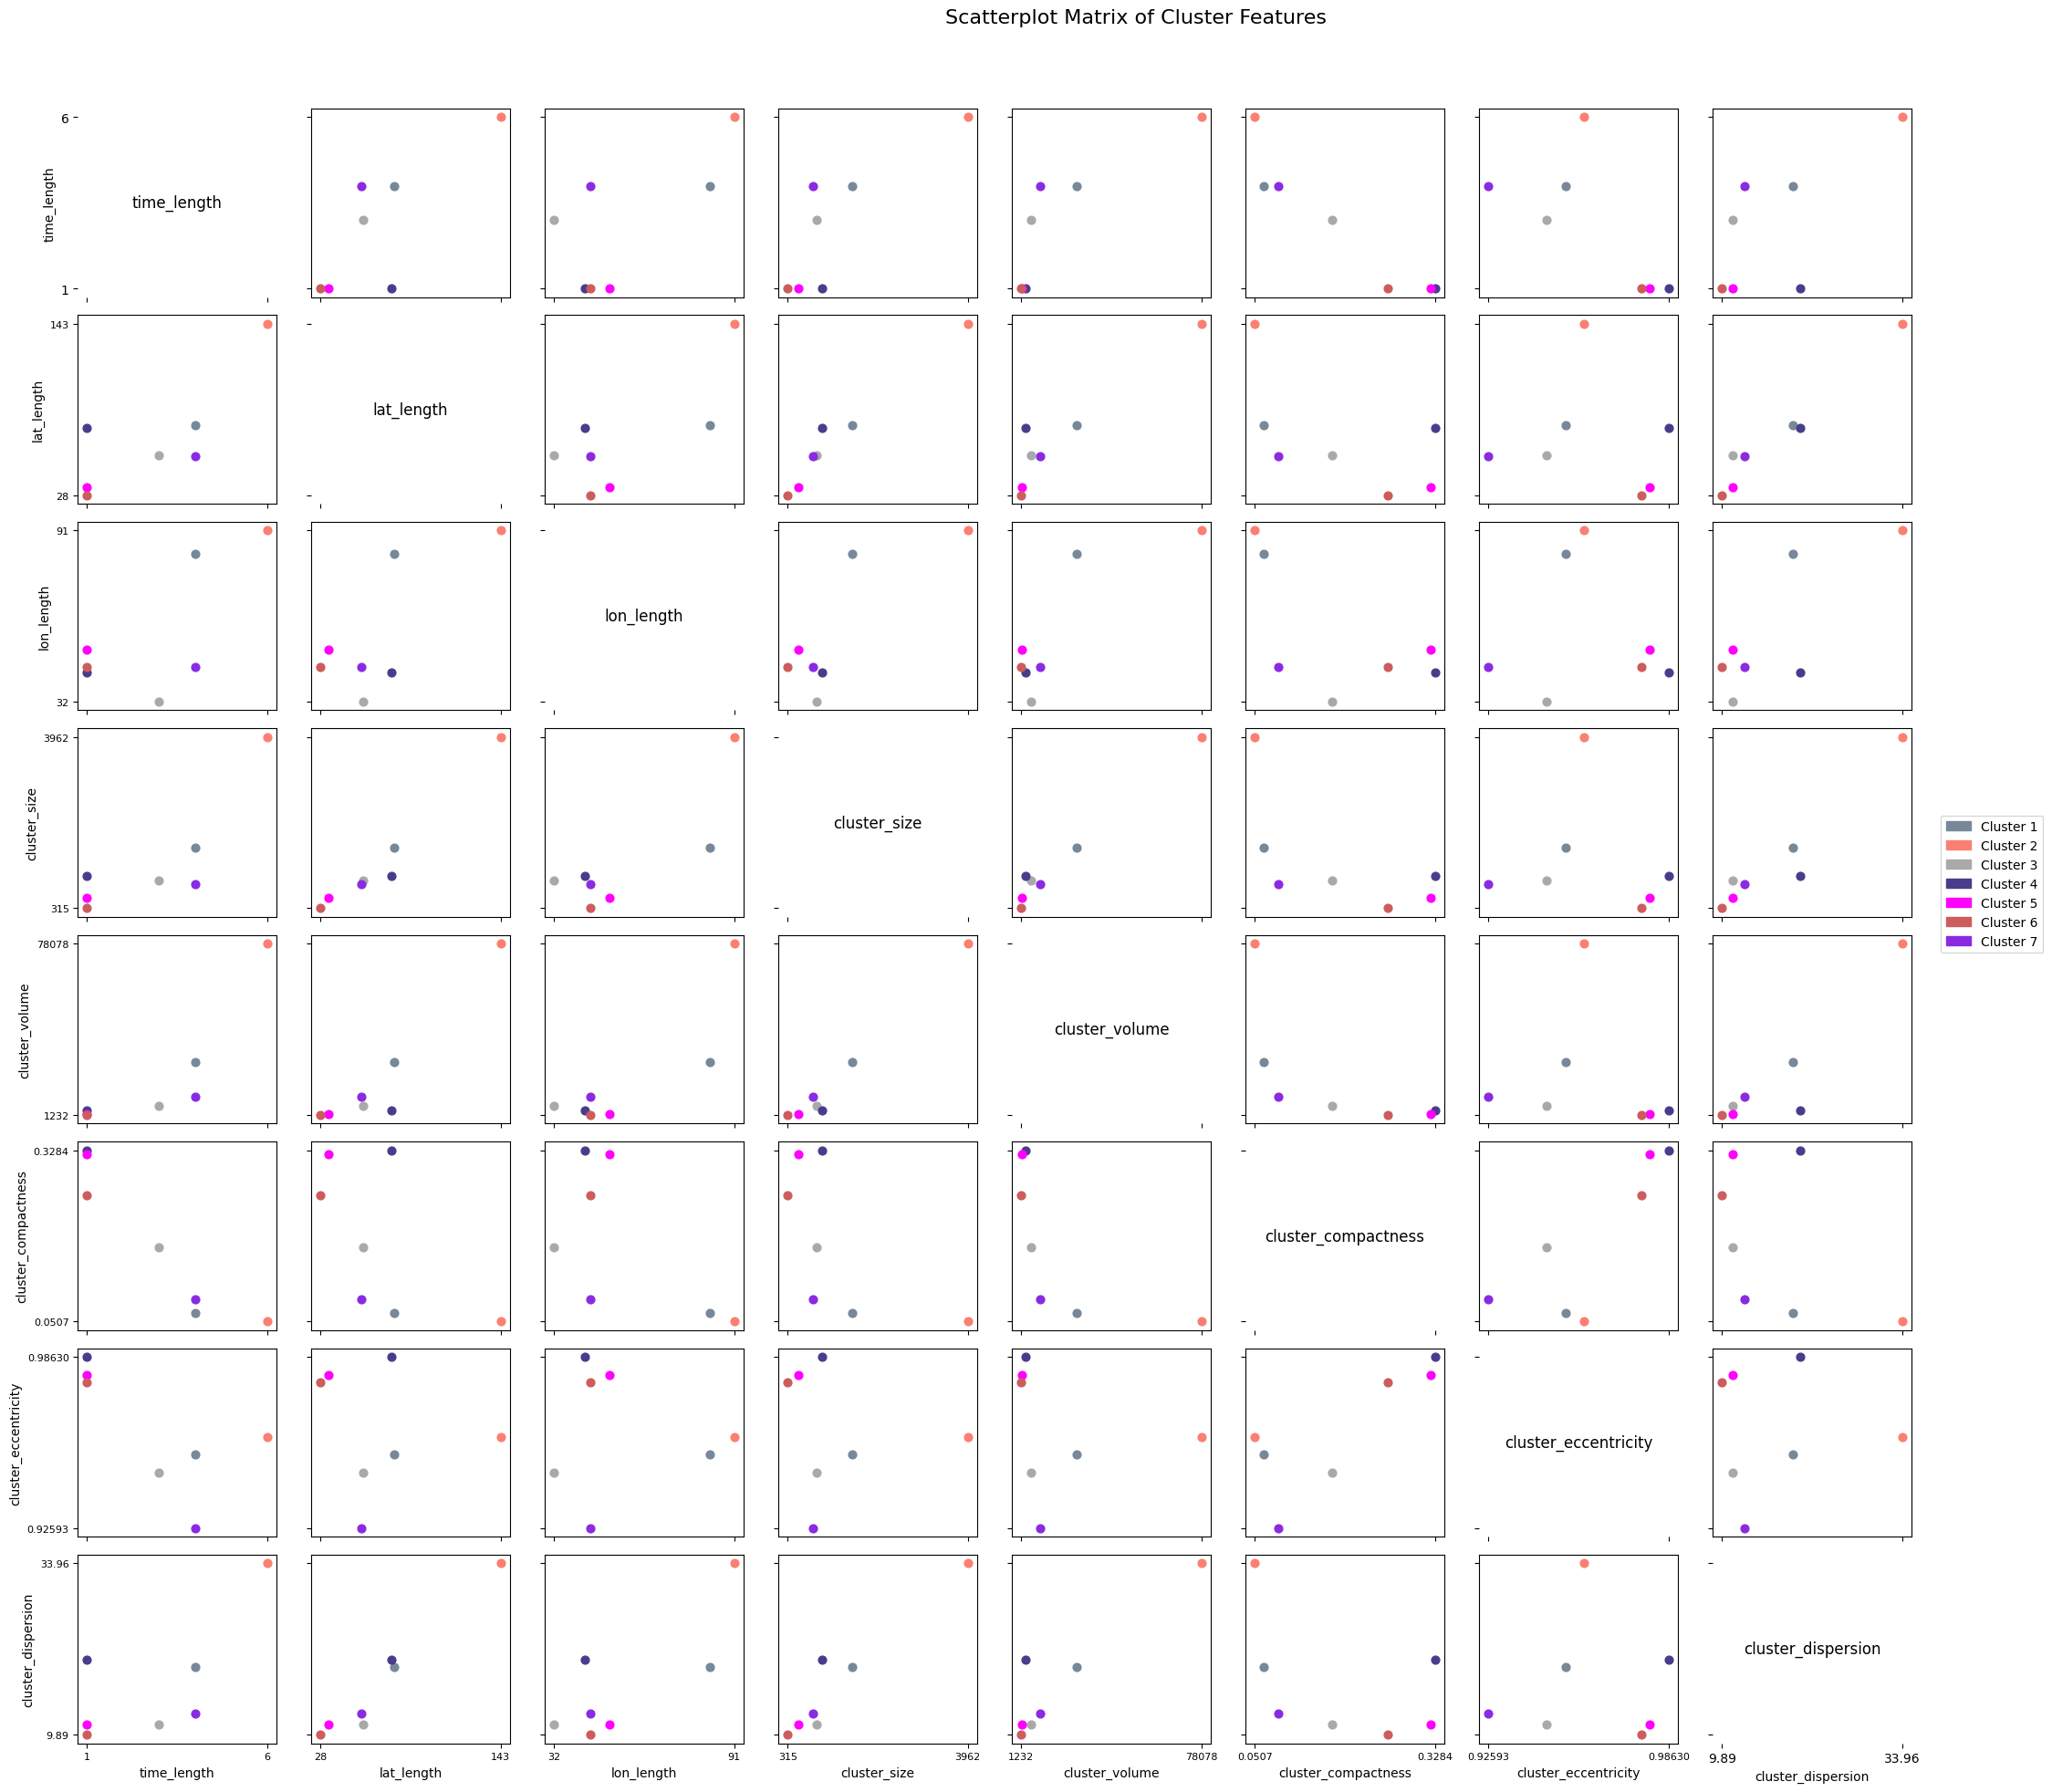




Experiment: (2) Much Larger Time Eps
File: clustering_experiment_2002-08-01_2025-01-01_sst-chlor_a_2-5_12_20_20_500_1.pkl
   time_length  lat_length  lon_length  cluster_size  cluster_volume  cluster_compactness  cluster_eccentricity  cluster_dispersion
1         16.0        81.0        85.0        1727.0        110160.0             0.015677              0.811765           21.507797
2          6.0       143.0        91.0        3985.0         78078.0             0.051039              0.958042           34.192083
3         12.0        56.0        39.0         947.0         26208.0             0.036134              0.785714           12.014864
4         43.0       101.0        85.0        2944.0        369155.0             0.007975              0.574257           29.127360
5         24.0       138.0        67.0        2391.0        221904.0             0.010775              0.826087           33.436380
6          5.0        53.0        55.0         657.0         14575.0             0.

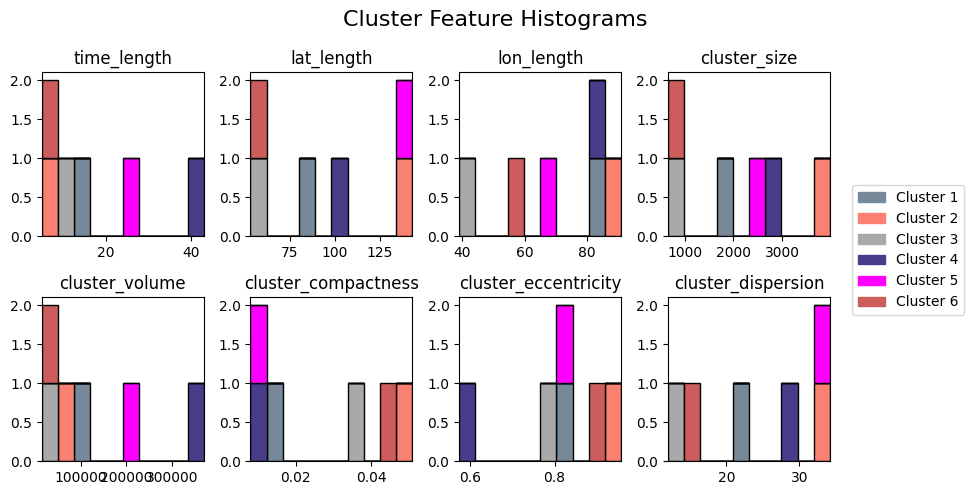

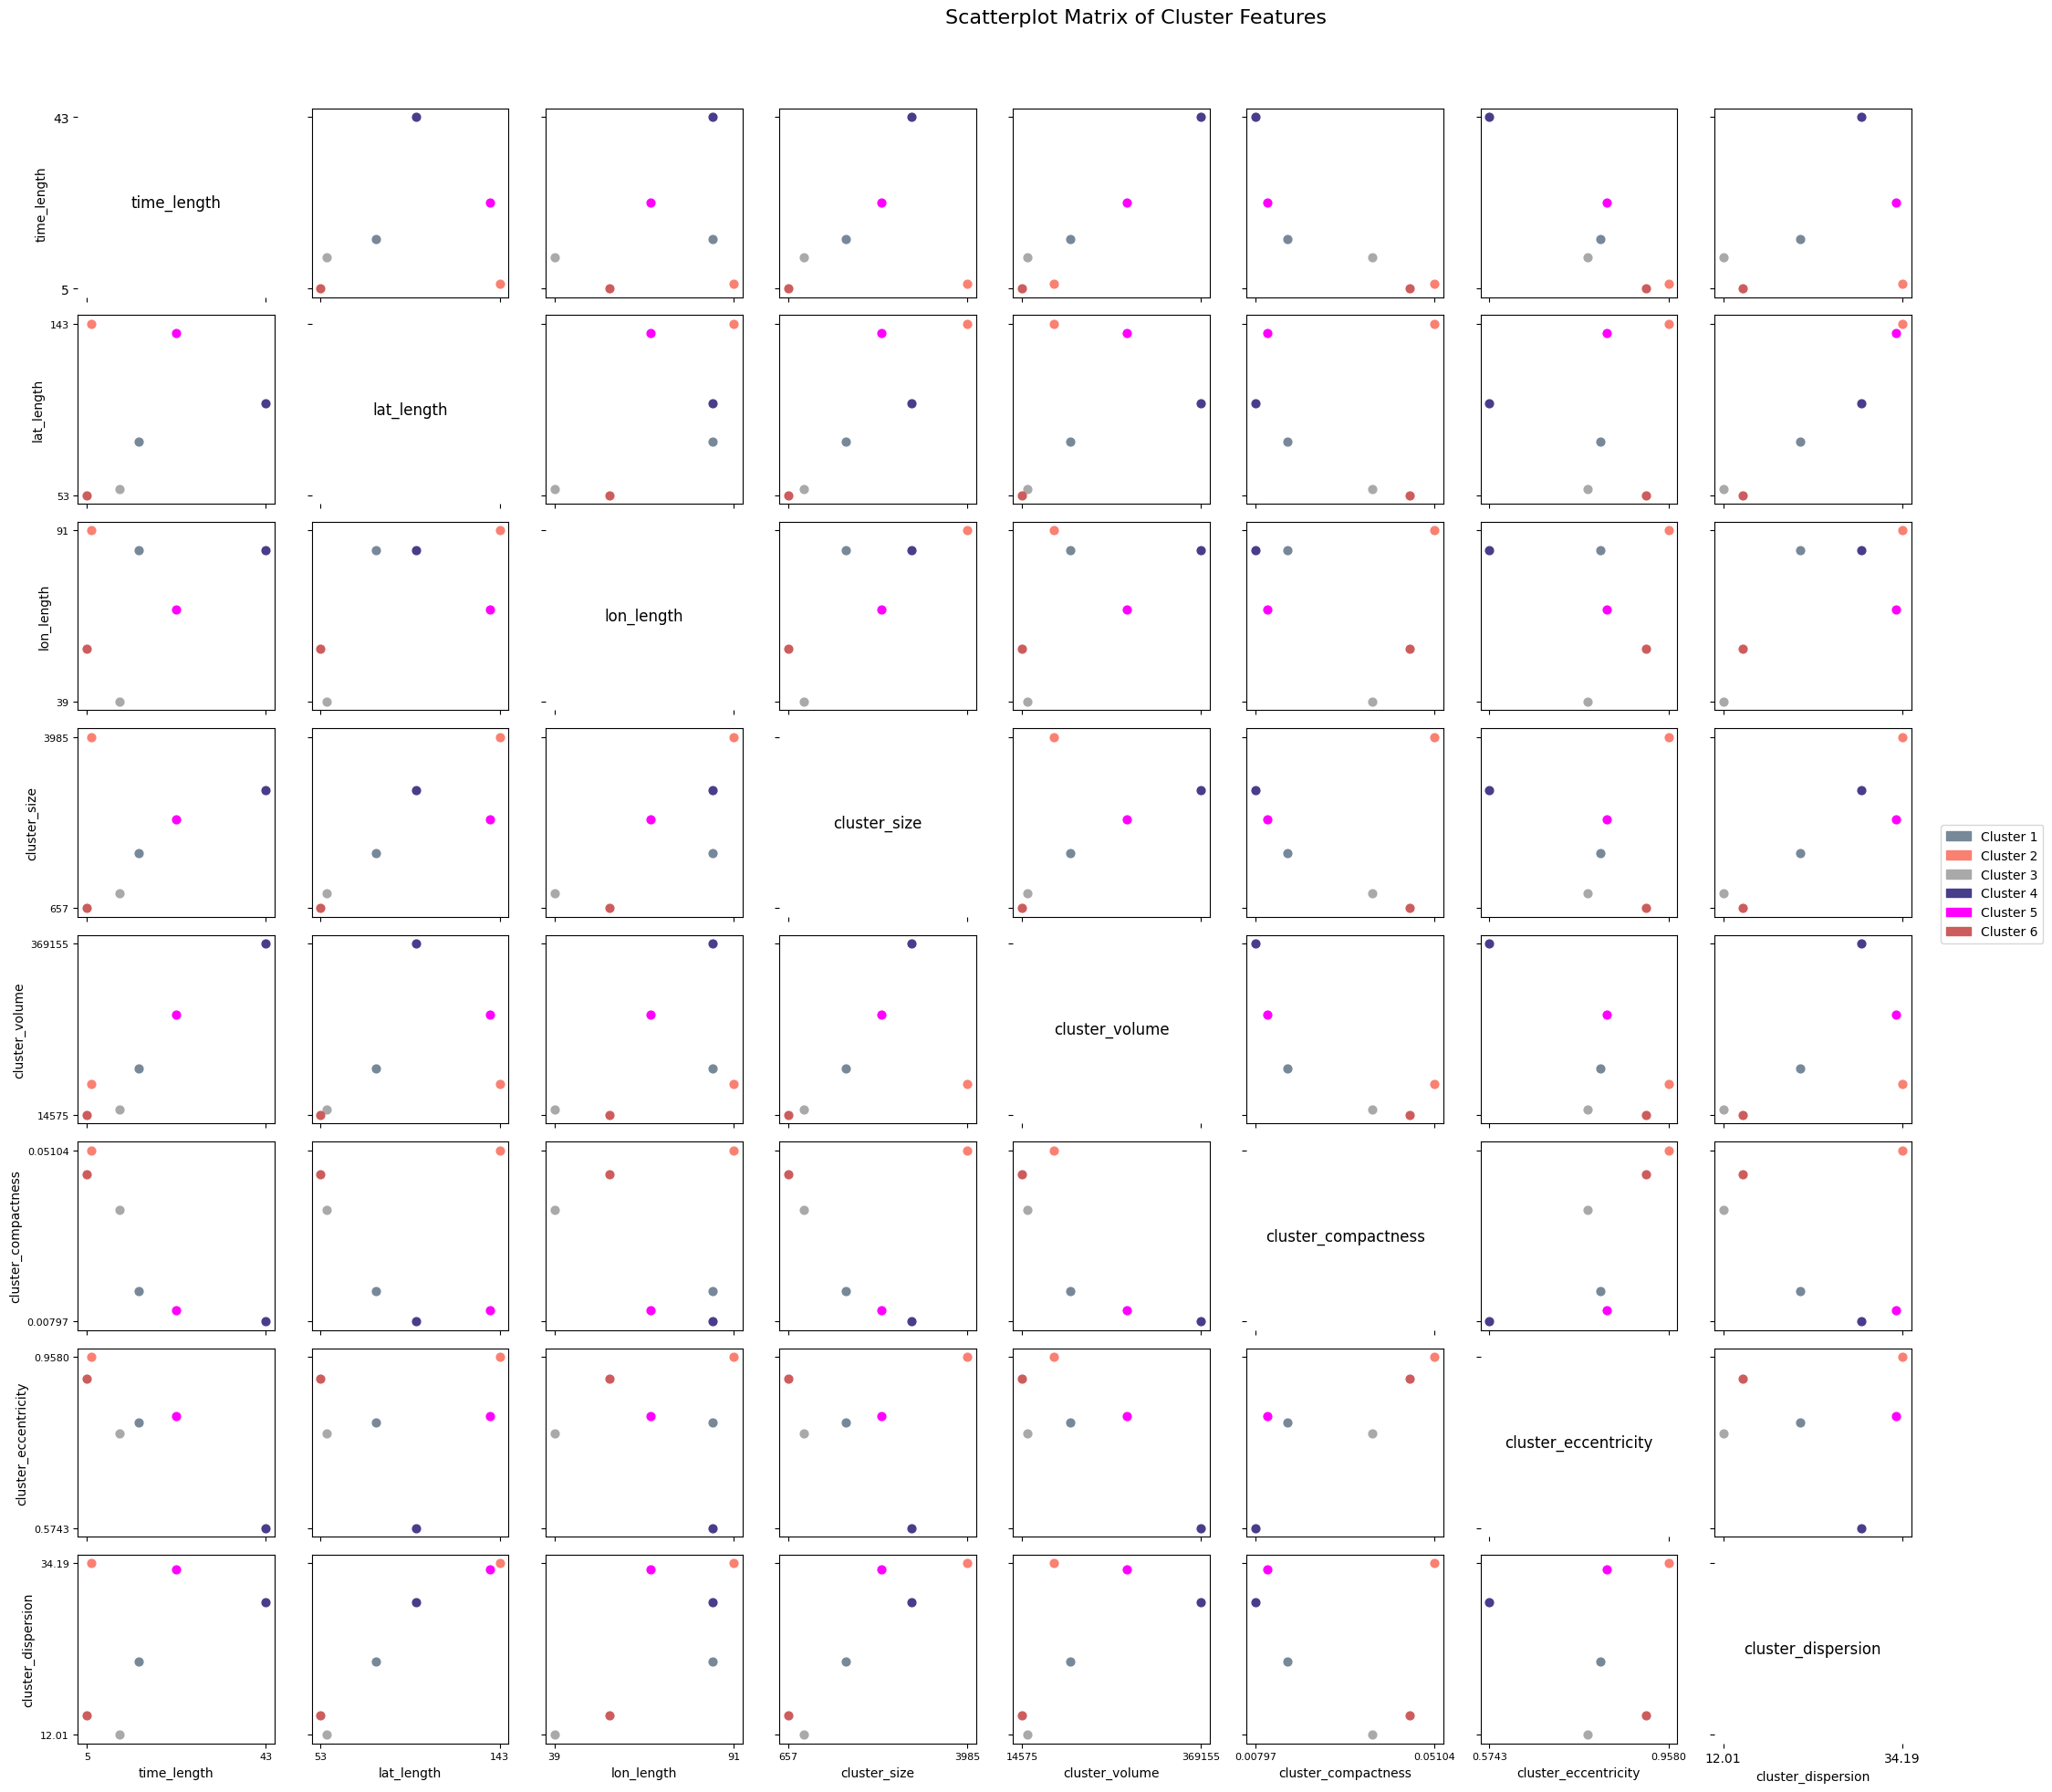

In [6]:
for experiment_feature in experiment_features:
    print(f"Experiment: {experiment_feature['experiment_name']}")
    print(f"File: {experiment_feature['file_name']}")
    plot_n_clustering_experiment_feature_report(experiment_feature['features'])
    print("\n\n")